In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df_inicial = pd.read_parquet('qtde_pessoas_familias_cadunico.parquet')

In [59]:
df_inicial.head()

,codigo_ibge,qtde_familias,qtde_pessoas,mes,ano,uf,municipio,sigla_uf,regiao
0,110001,4116,14076,12,2012,Rondônia,Alta Floresta D'Oeste,RO,Norte
1,110002,10775,37567,12,2012,Rondônia,Ariquemes,RO,Norte
2,110003,993,3313,12,2012,Rondônia,Cabixi,RO,Norte
3,110004,8516,29459,12,2012,Rondônia,Cacoal,RO,Norte
4,110005,2259,7918,12,2012,Rondônia,Cerejeiras,RO,Norte


In [60]:
df_qtde_por_ano = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars='ano',
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo'])
    .agg('sum')
    .reset_index()
)

In [61]:
df_qtde_por_ano.head()

,ano,grupo,qtde
0,2012,Pessoas,81322507
1,2012,Famílias,25063802
2,2013,Pessoas,85057820
3,2013,Famílias,27194588
4,2014,Pessoas,88339340


In [62]:
df_qtde_por_ano.dtypes

ano         int64
grupo    category
qtde        int64
dtype: object

In [63]:
df_qtde_por_ano['qtde'] = pd.to_numeric(df_qtde_por_ano['qtde'], downcast='integer')

In [64]:
df_qtde_por_ano['qtde_1e6'] = df_qtde_por_ano['qtde'] / 1e6

In [65]:
df_qtde_por_ano.dtypes

ano            int64
grupo       category
qtde           int32
qtde_1e6     float64
dtype: object

In [66]:
anos = sorted(df_inicial['ano'].unique().tolist())
print(anos)

[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


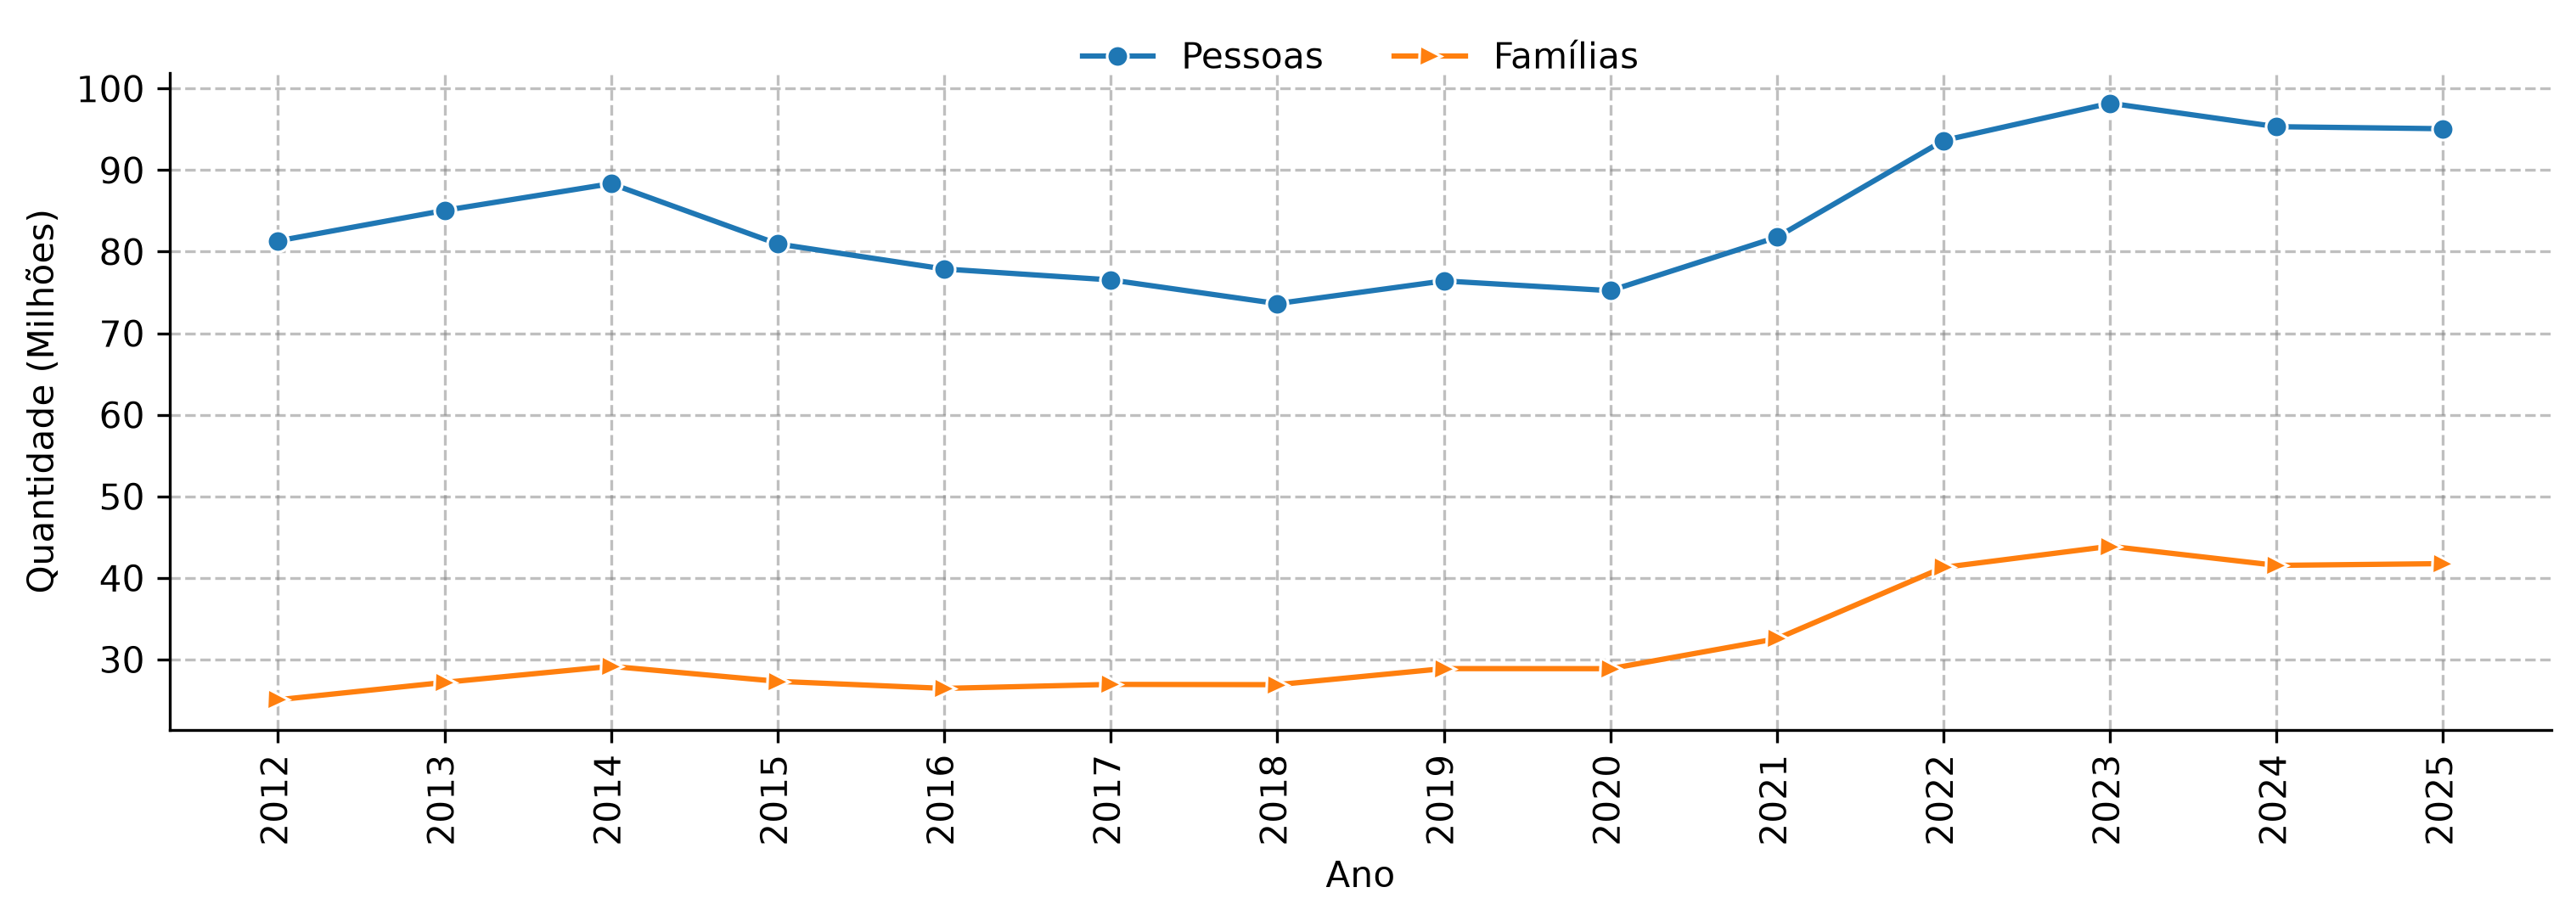

In [67]:
fig, ax = plt.subplots(
    figsize=(10, 3.5),
    dpi=300,
    layout='constrained'
)

sns.lineplot(
    df_qtde_por_ano,
    x='ano',
    y='qtde_1e6',
    hue='grupo',
    style='grupo',
    markers=['o', '>'],
    errorbar=None,
    dashes=False,
    ax=ax
)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('Quantidade (Milhões)')
ax.set_xlabel('Ano')
ax.set_xticks(anos, labels=anos, rotation=90)
ax.grid(color='grey', linestyle='--', alpha=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=2, frameon=False)

fig.savefig('pessoas_familias_cadunico', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
df_qtde_por_ano_regiao = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars=['ano', 'regiao'],
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo', 'regiao'])
    .agg('sum')
    .reset_index()
    .assign(
        qtde = lambda x: pd.to_numeric(
            x['qtde'], 
            downcast='integer'
        ),
        qtde_1e6 = lambda x: x['qtde'] / 1e6
    )
)

In [69]:
df_qtde_por_ano_regiao.head()

,ano,grupo,regiao,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,5378848,5.378848
1,2012,Pessoas,Nordeste,34445665,34.445665
2,2012,Pessoas,Norte,8612913,8.612913
3,2012,Pessoas,Sudeste,24492487,24.492487
4,2012,Pessoas,Sul,8392594,8.392594


In [70]:
df_qtde_por_ano_regiao.dtypes

ano            int64
grupo       category
regiao           str
qtde           int32
qtde_1e6     float64
dtype: object

Centro-oeste
<class 'pandas.DataFrame'>


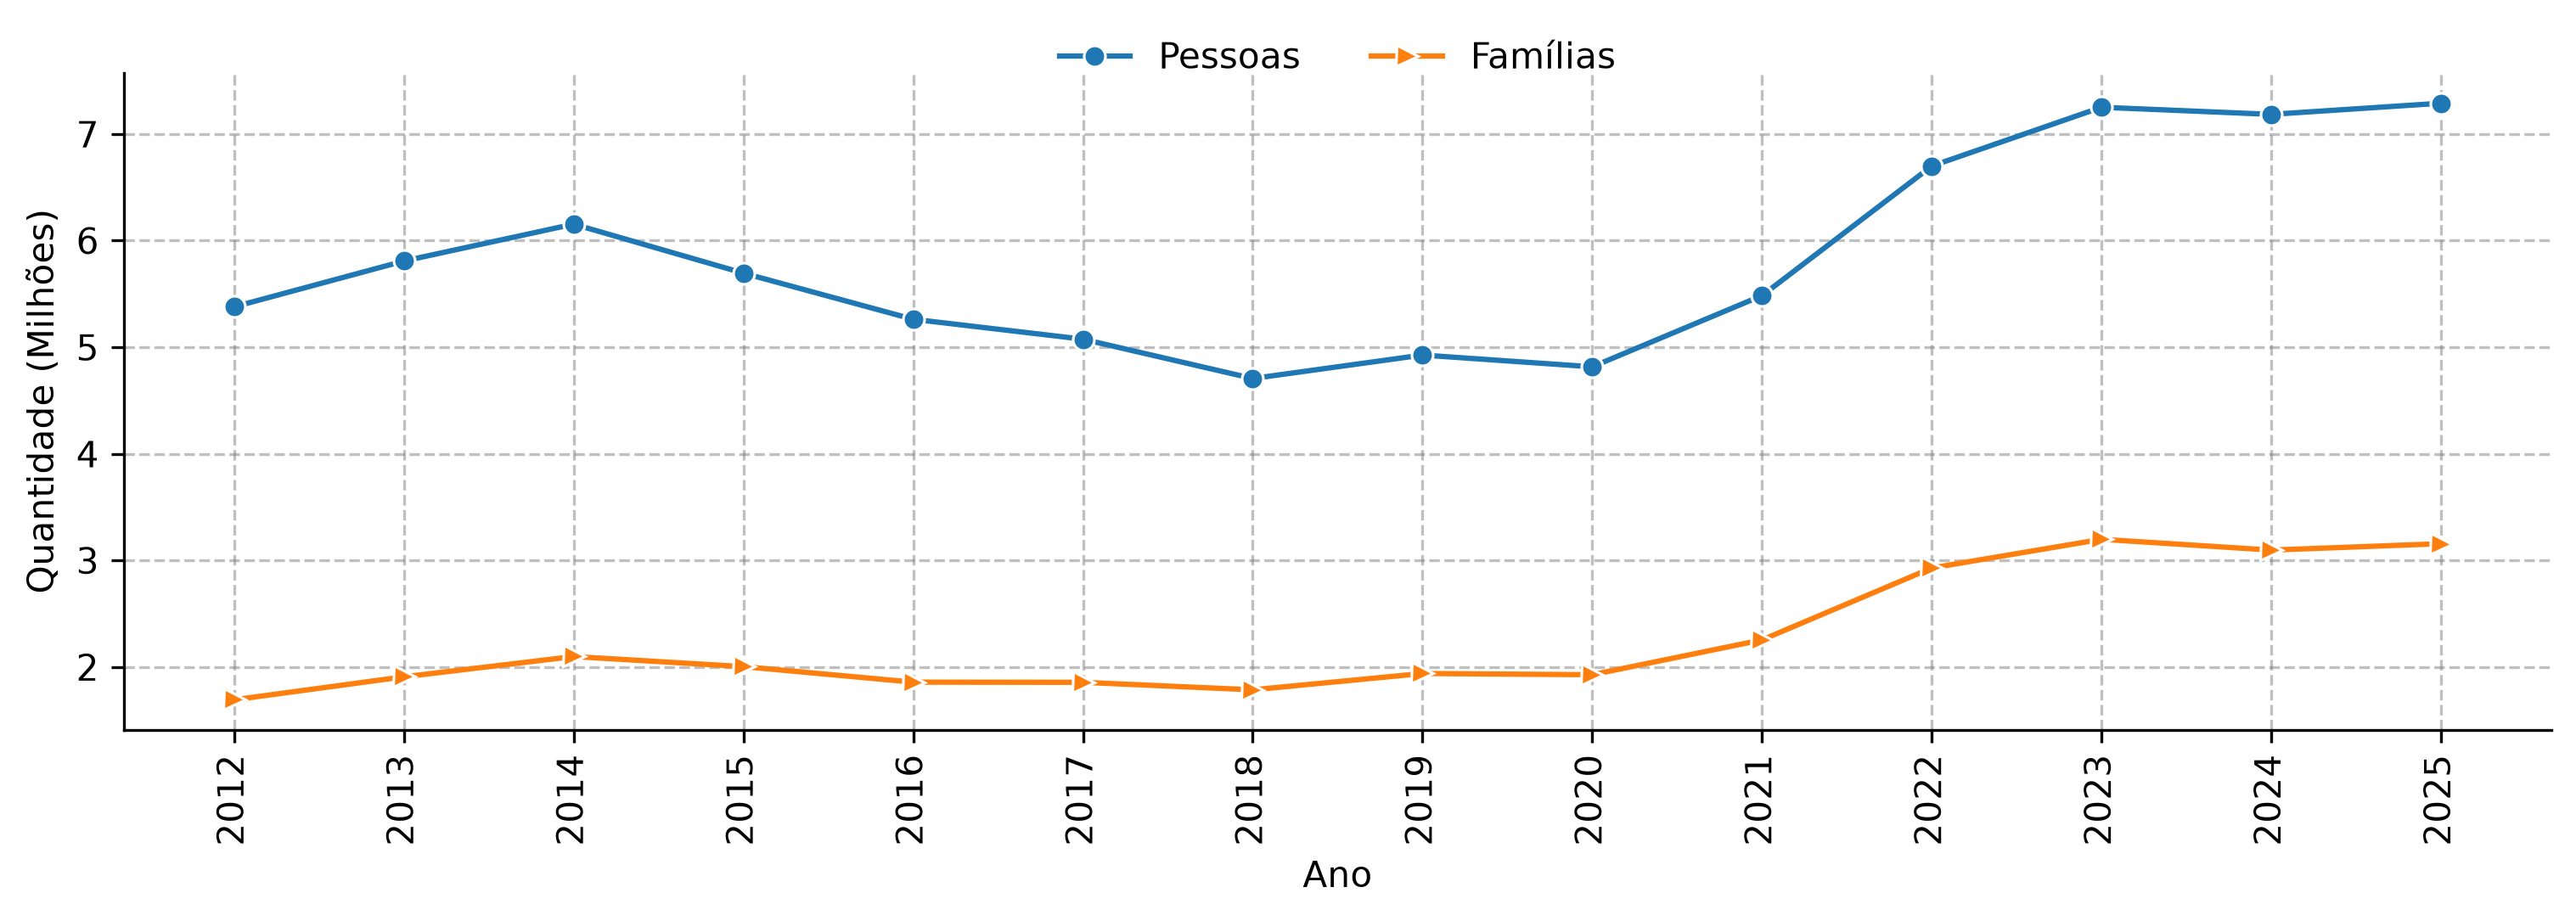

Nordeste
<class 'pandas.DataFrame'>


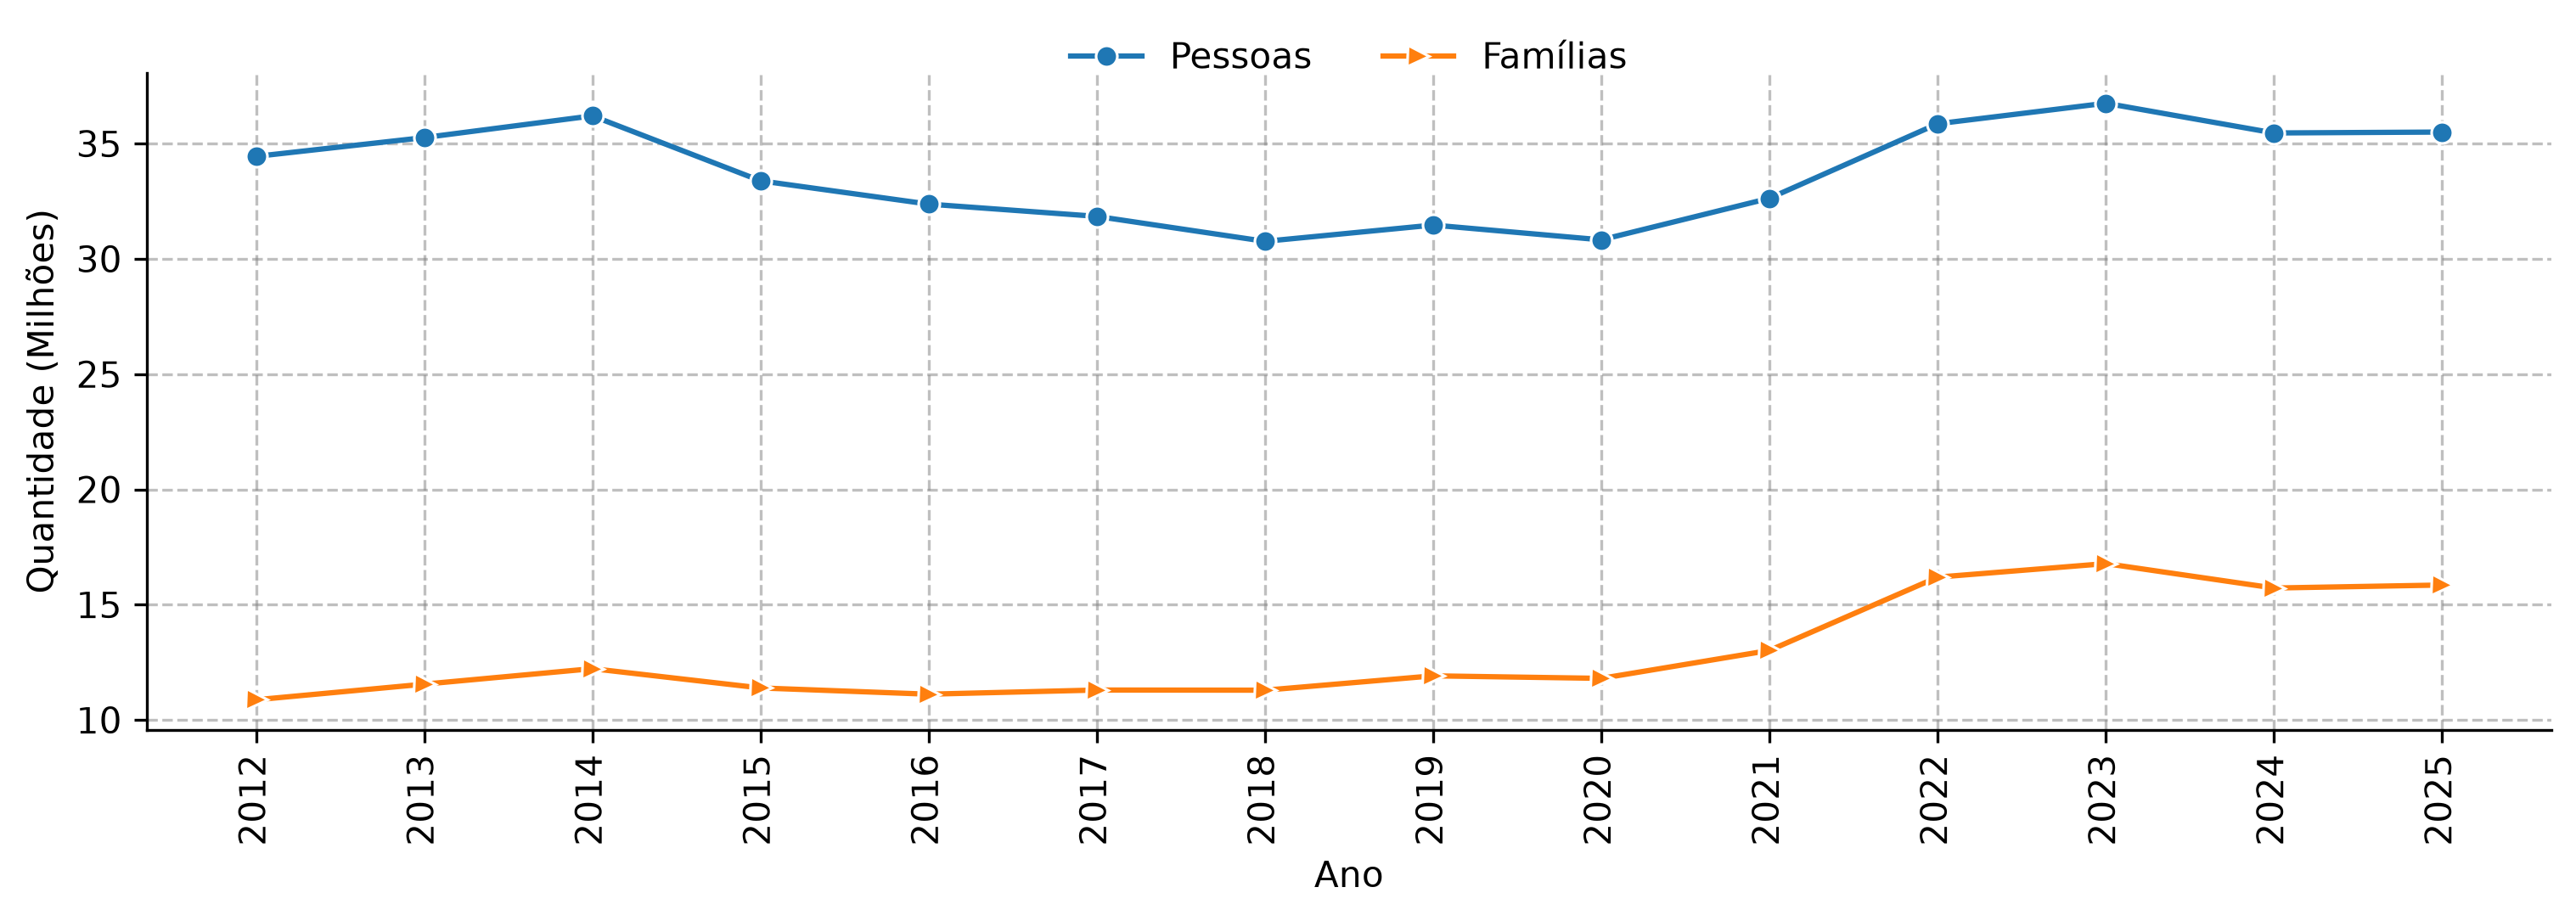

Norte
<class 'pandas.DataFrame'>


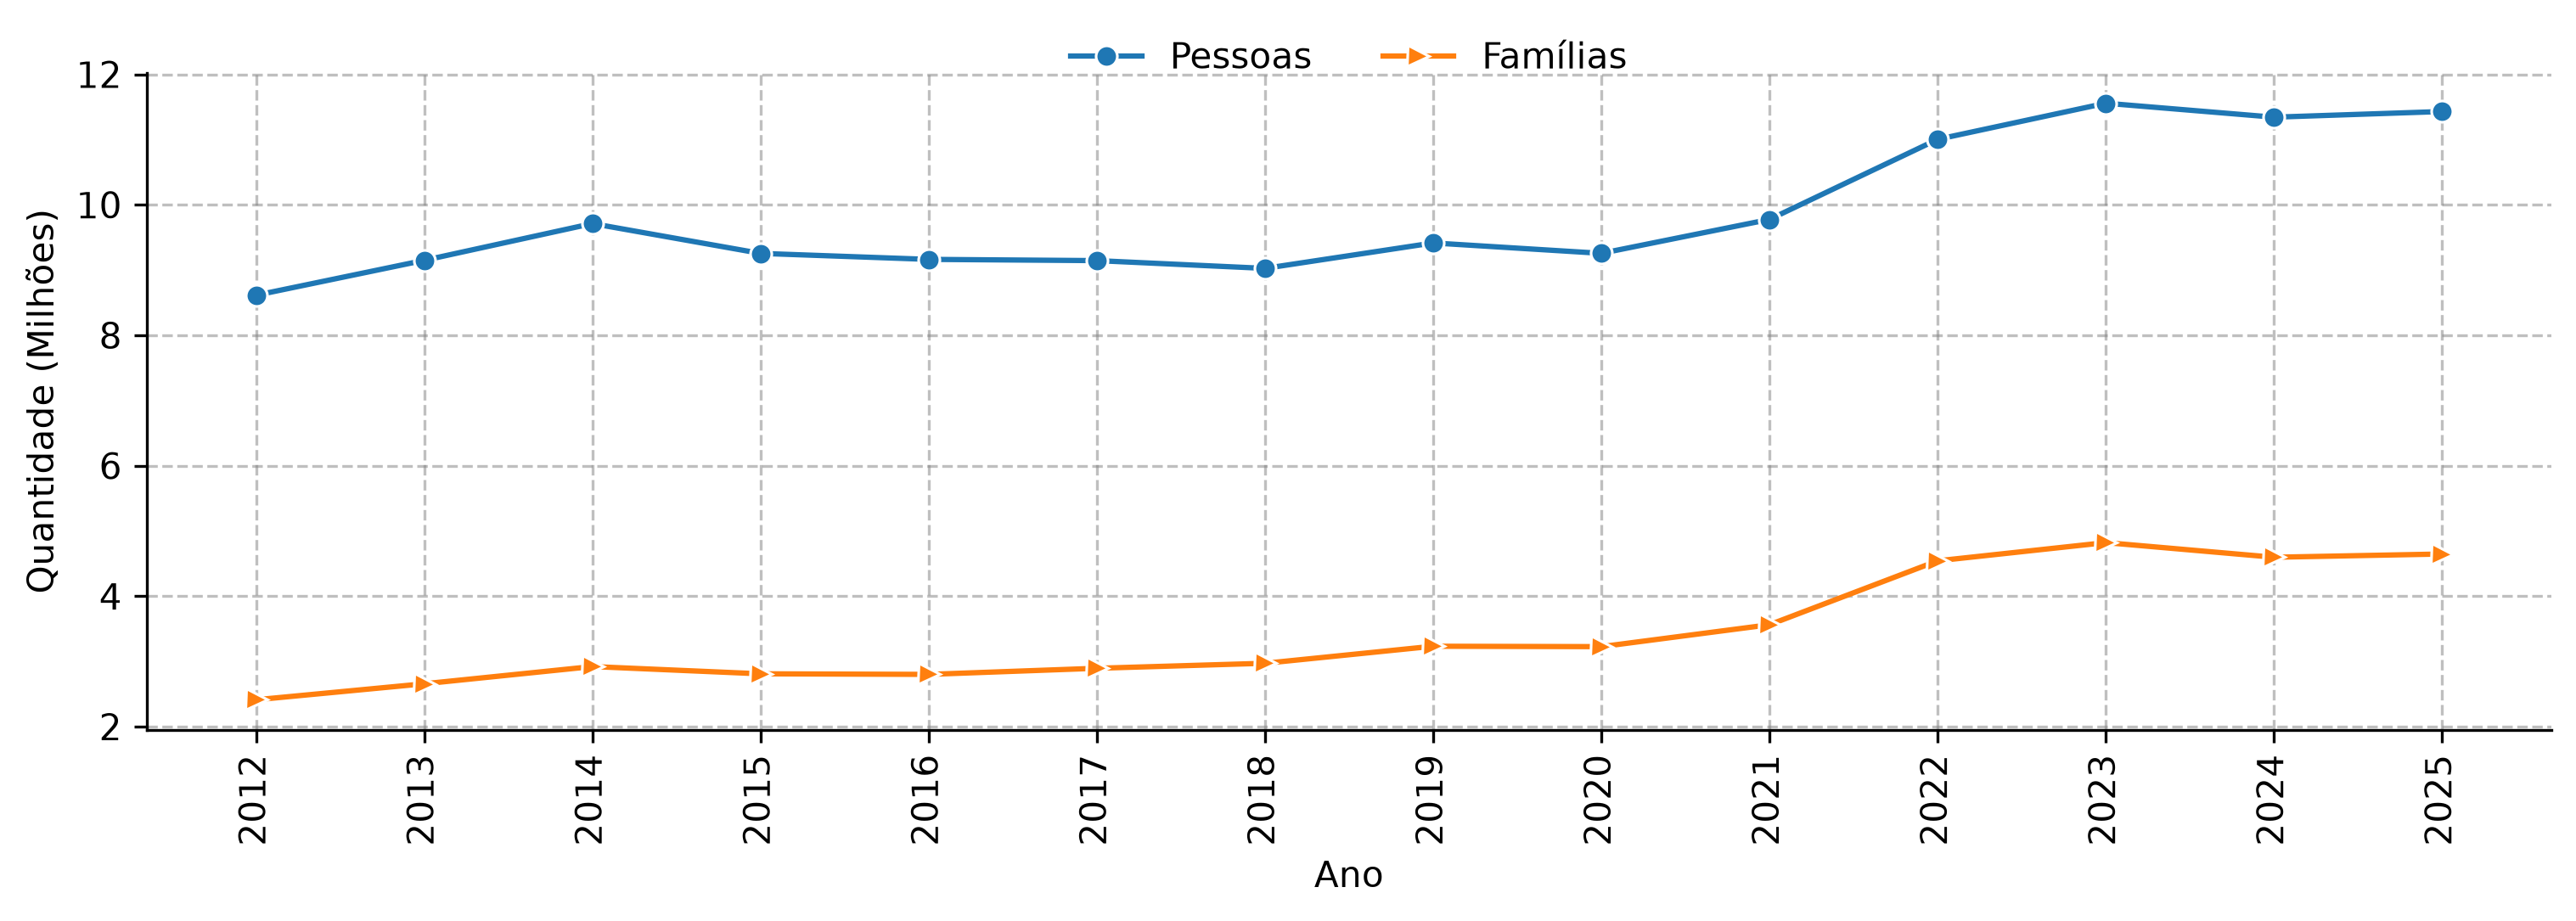

Sudeste
<class 'pandas.DataFrame'>


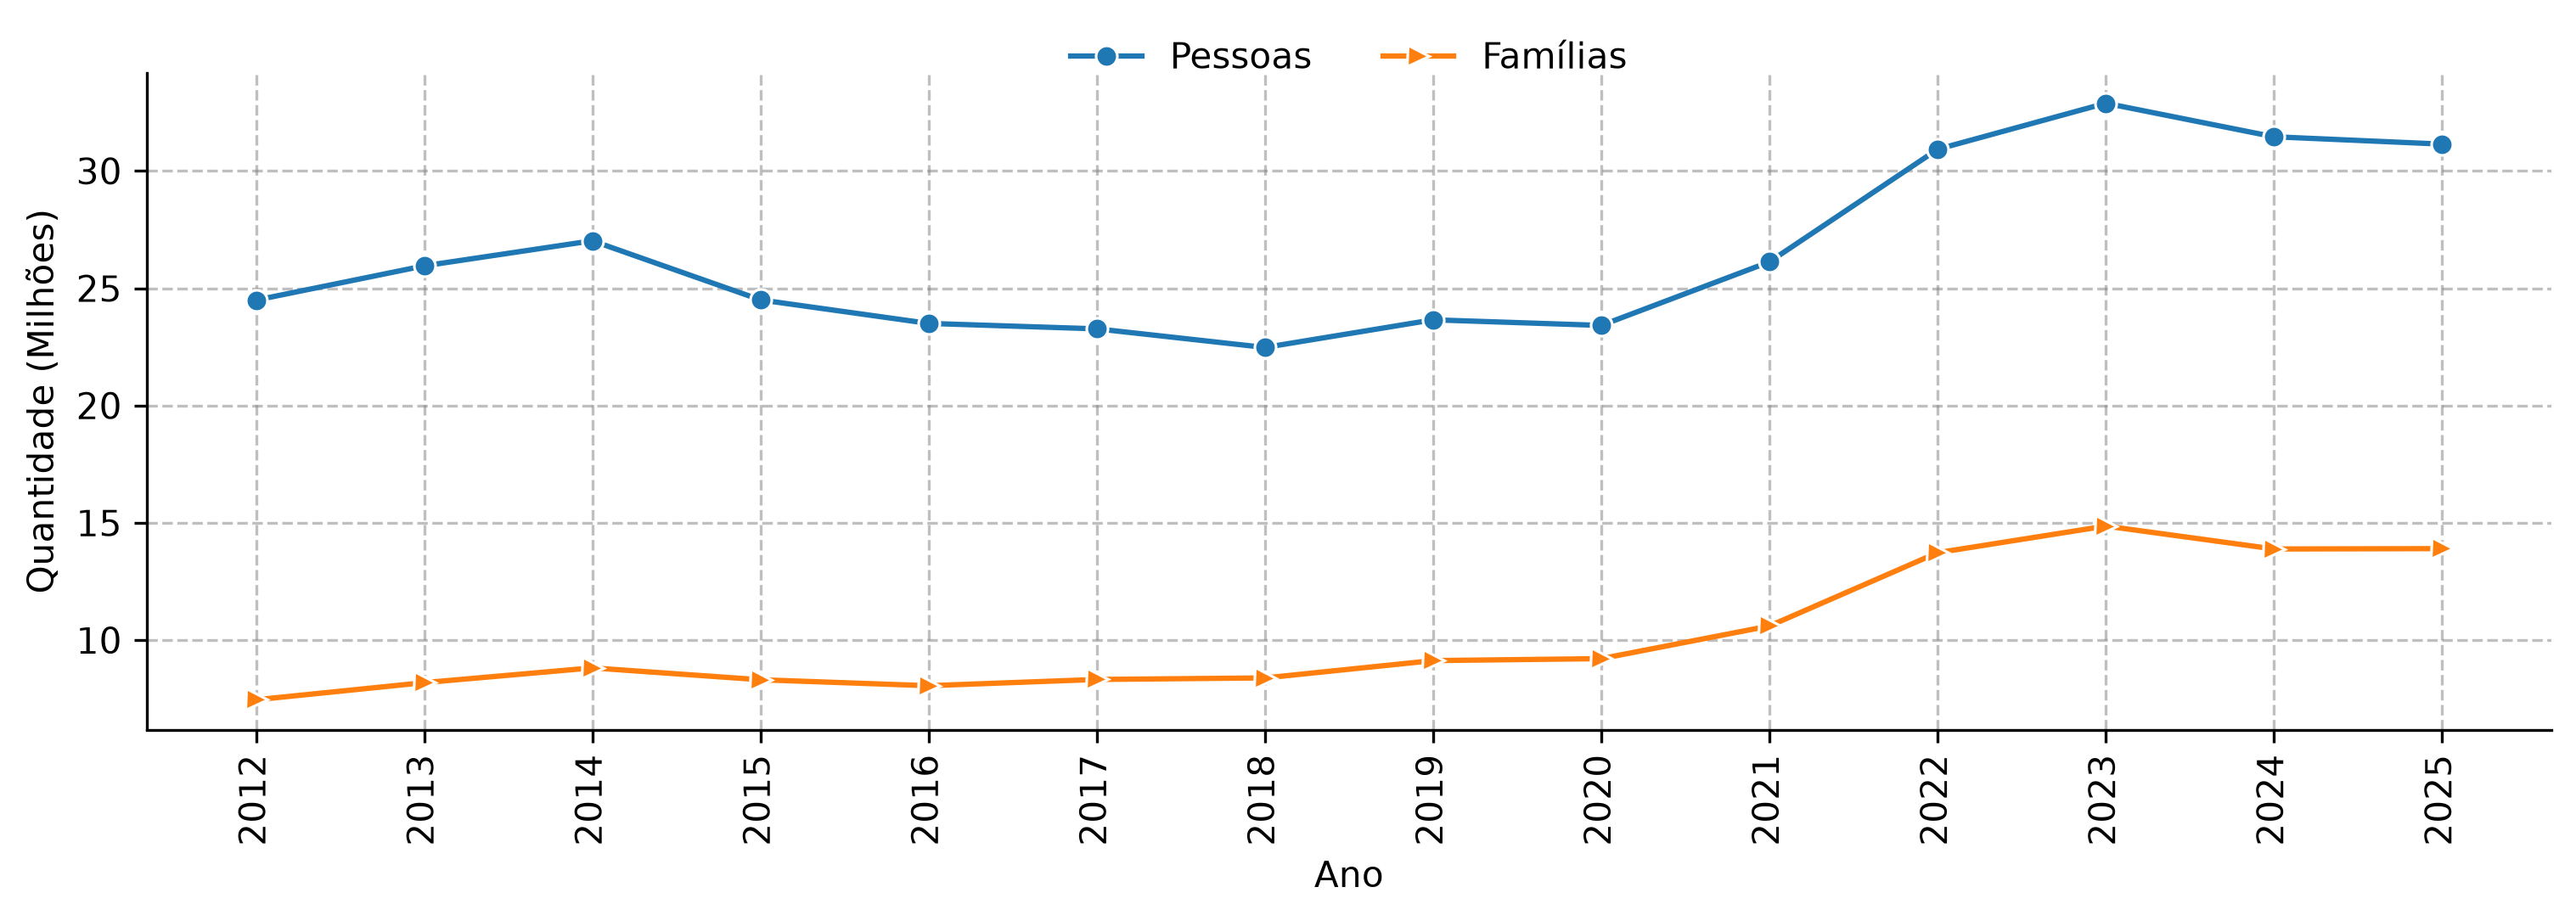

Sul
<class 'pandas.DataFrame'>


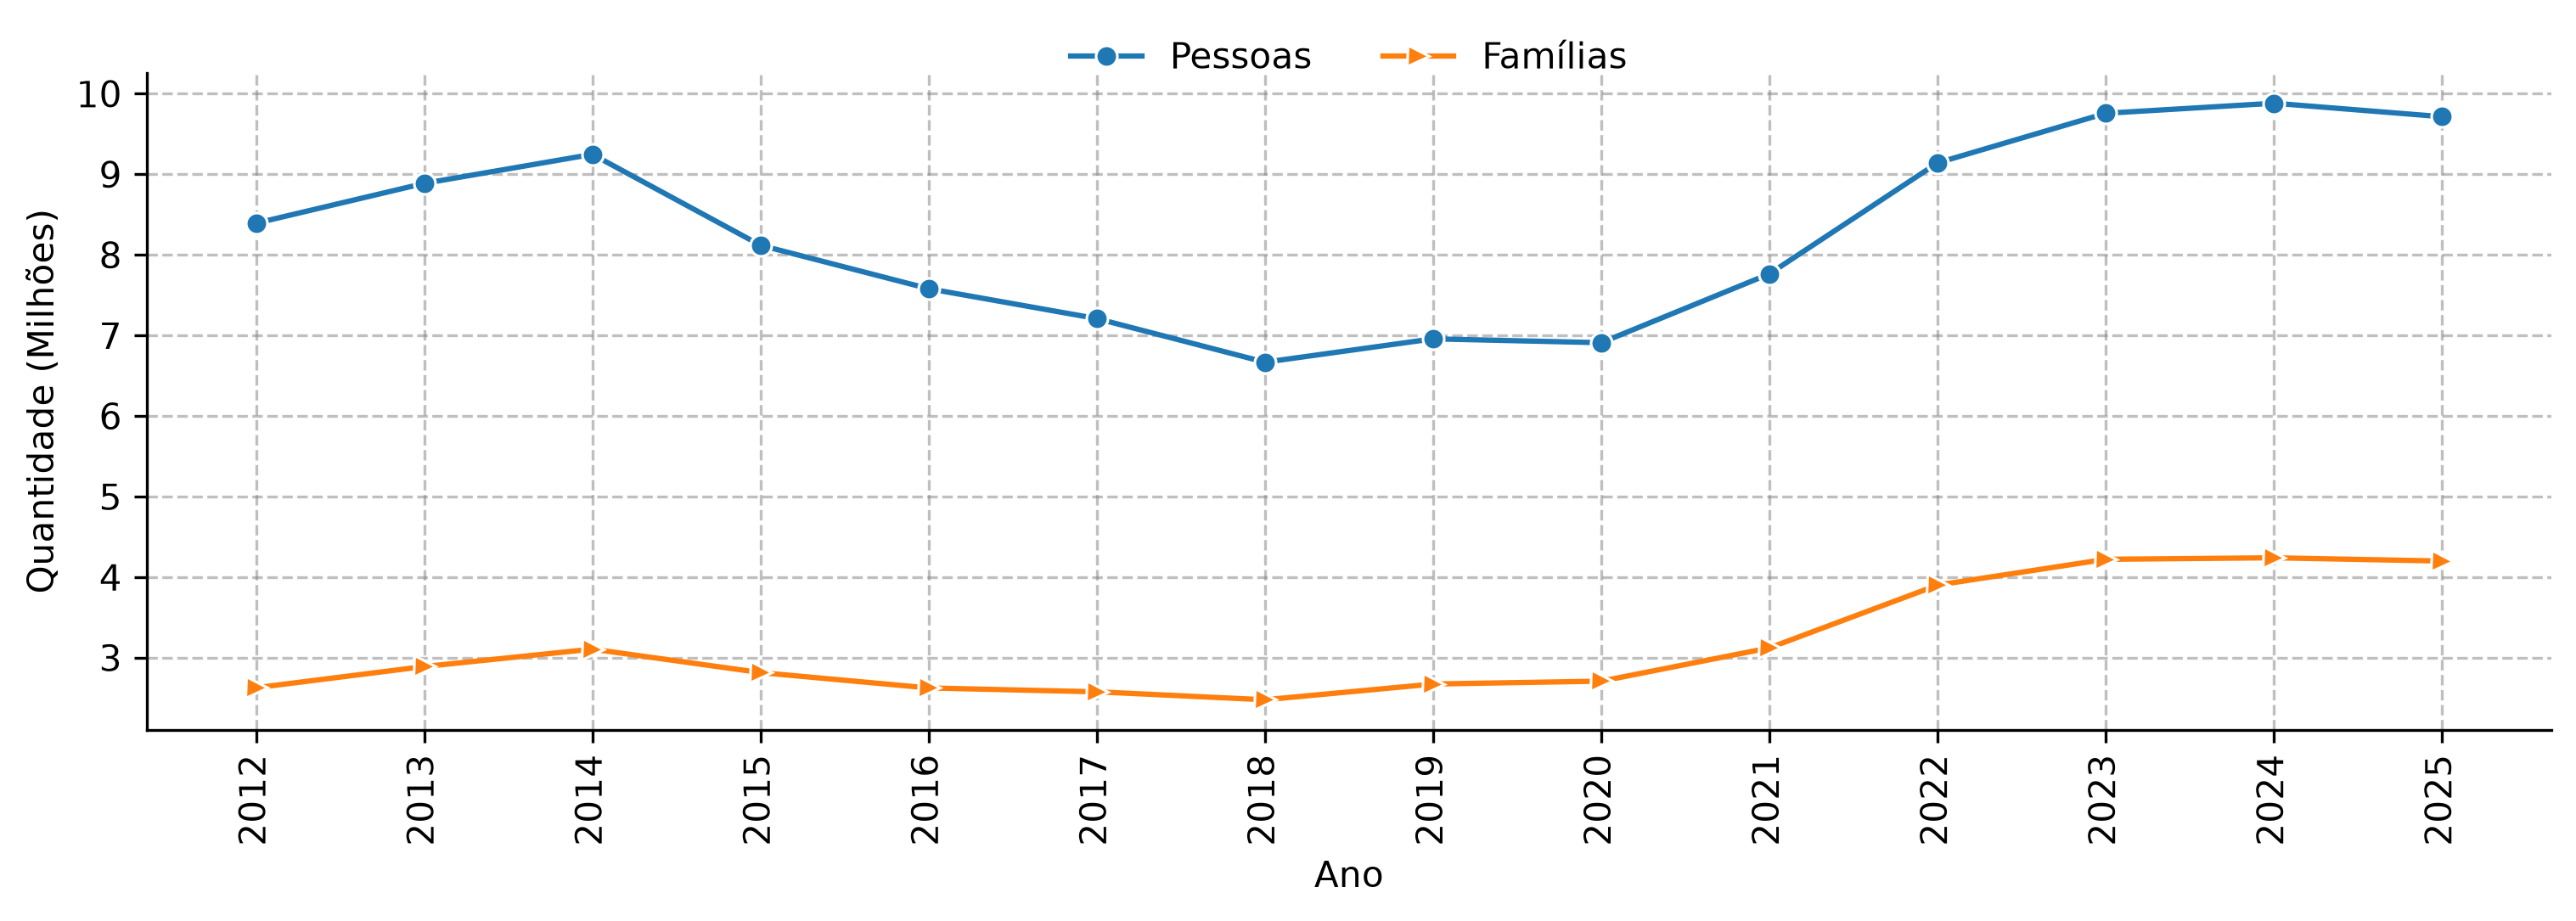

In [71]:
for (regiao, df_por_regiao) in df_qtde_por_ano_regiao.groupby('regiao'):
    print(regiao)
    print(type(df_por_regiao))

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='grupo',
        style='grupo',
        markers=['o', '>'],
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=2, frameon=False)

    fig.savefig(f'pessoas_familias_cadunico_{regiao.lower()}', dpi=300, bbox_inches='tight')
    plt.show()

In [72]:
df_qtde_por_ano_regiao_uf = (
    df_inicial.query('''
        mes == 12
    ''')
    .melt(
        id_vars=['ano', 'regiao', 'sigla_uf'],
        value_vars=['qtde_pessoas', 'qtde_familias'],
        var_name='grupo',
        value_name='qtde'
    )
    .replace({
        'qtde_pessoas': 'Pessoas',
        'qtde_familias': 'Famílias'
    })
    .assign(grupo = lambda x: pd.Categorical(
        x['grupo'], 
        categories=['Pessoas', 'Famílias'])
    )
    .groupby(['ano', 'grupo', 'regiao', 'sigla_uf'])
    .agg('sum')
    .reset_index()
    .assign(
        qtde = lambda x: pd.to_numeric(
            x['qtde'], 
            downcast='integer'
        ),
        qtde_1e6 = lambda x: x['qtde'] / 1e6
    )
)

In [73]:
df_qtde_por_ano_regiao_uf.head()

,ano,grupo,regiao,sigla_uf,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,DF,804338,0.804338
1,2012,Pessoas,Centro-oeste,GO,2331853,2.331853
2,2012,Pessoas,Centro-oeste,MS,989919,0.989919
3,2012,Pessoas,Centro-oeste,MT,1252738,1.252738
4,2012,Pessoas,Nordeste,AL,2055315,2.055315


In [74]:
df_qtde_por_ano_regiao_uf_grupo_pessoas = df_qtde_por_ano_regiao_uf.query('grupo == "Pessoas"')

In [75]:
df_qtde_por_ano_regiao_uf_grupo_pessoas.head()

,ano,grupo,regiao,sigla_uf,qtde,qtde_1e6
0,2012,Pessoas,Centro-oeste,DF,804338,0.804338
1,2012,Pessoas,Centro-oeste,GO,2331853,2.331853
2,2012,Pessoas,Centro-oeste,MS,989919,0.989919
3,2012,Pessoas,Centro-oeste,MT,1252738,1.252738
4,2012,Pessoas,Nordeste,AL,2055315,2.055315


Centro-oeste


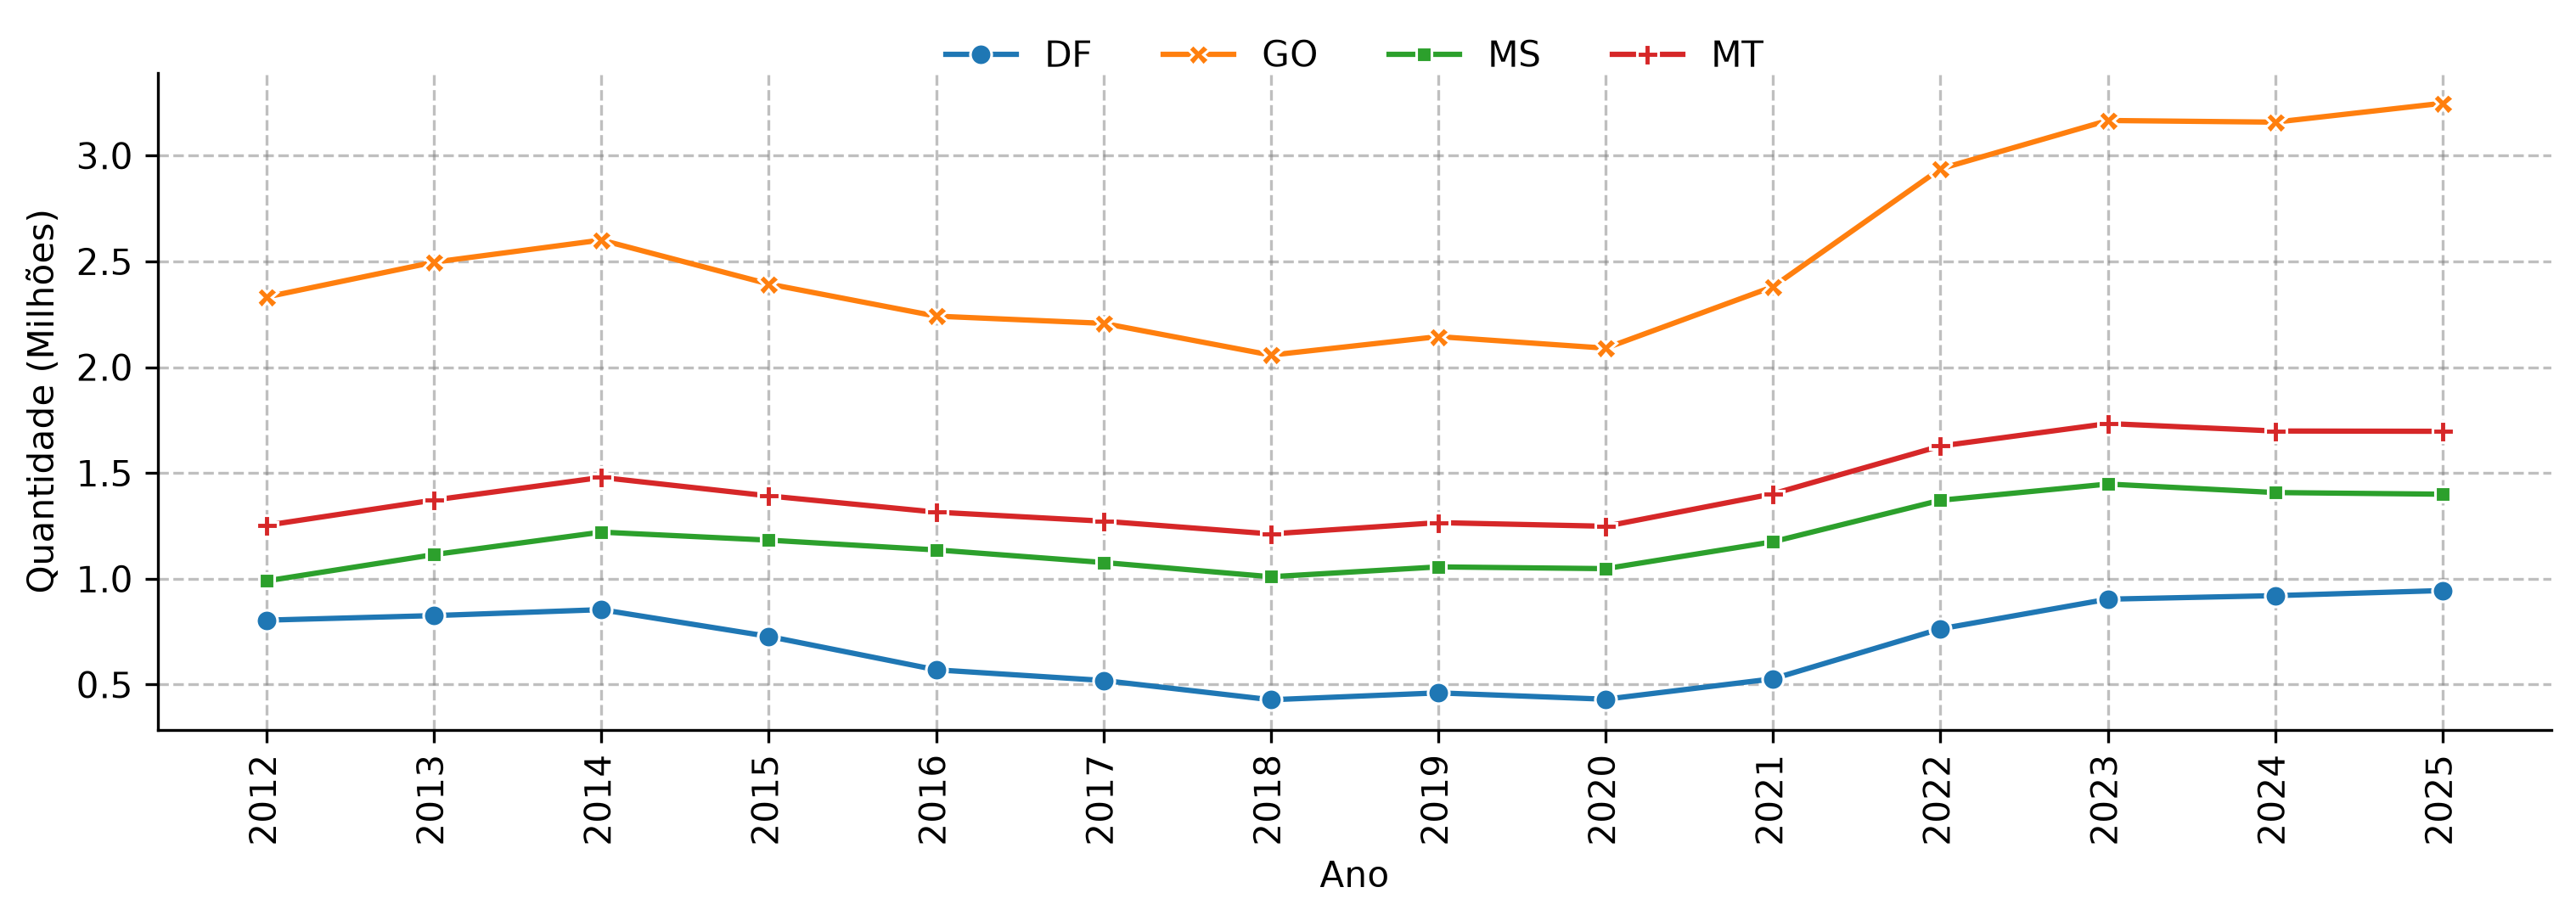

Nordeste


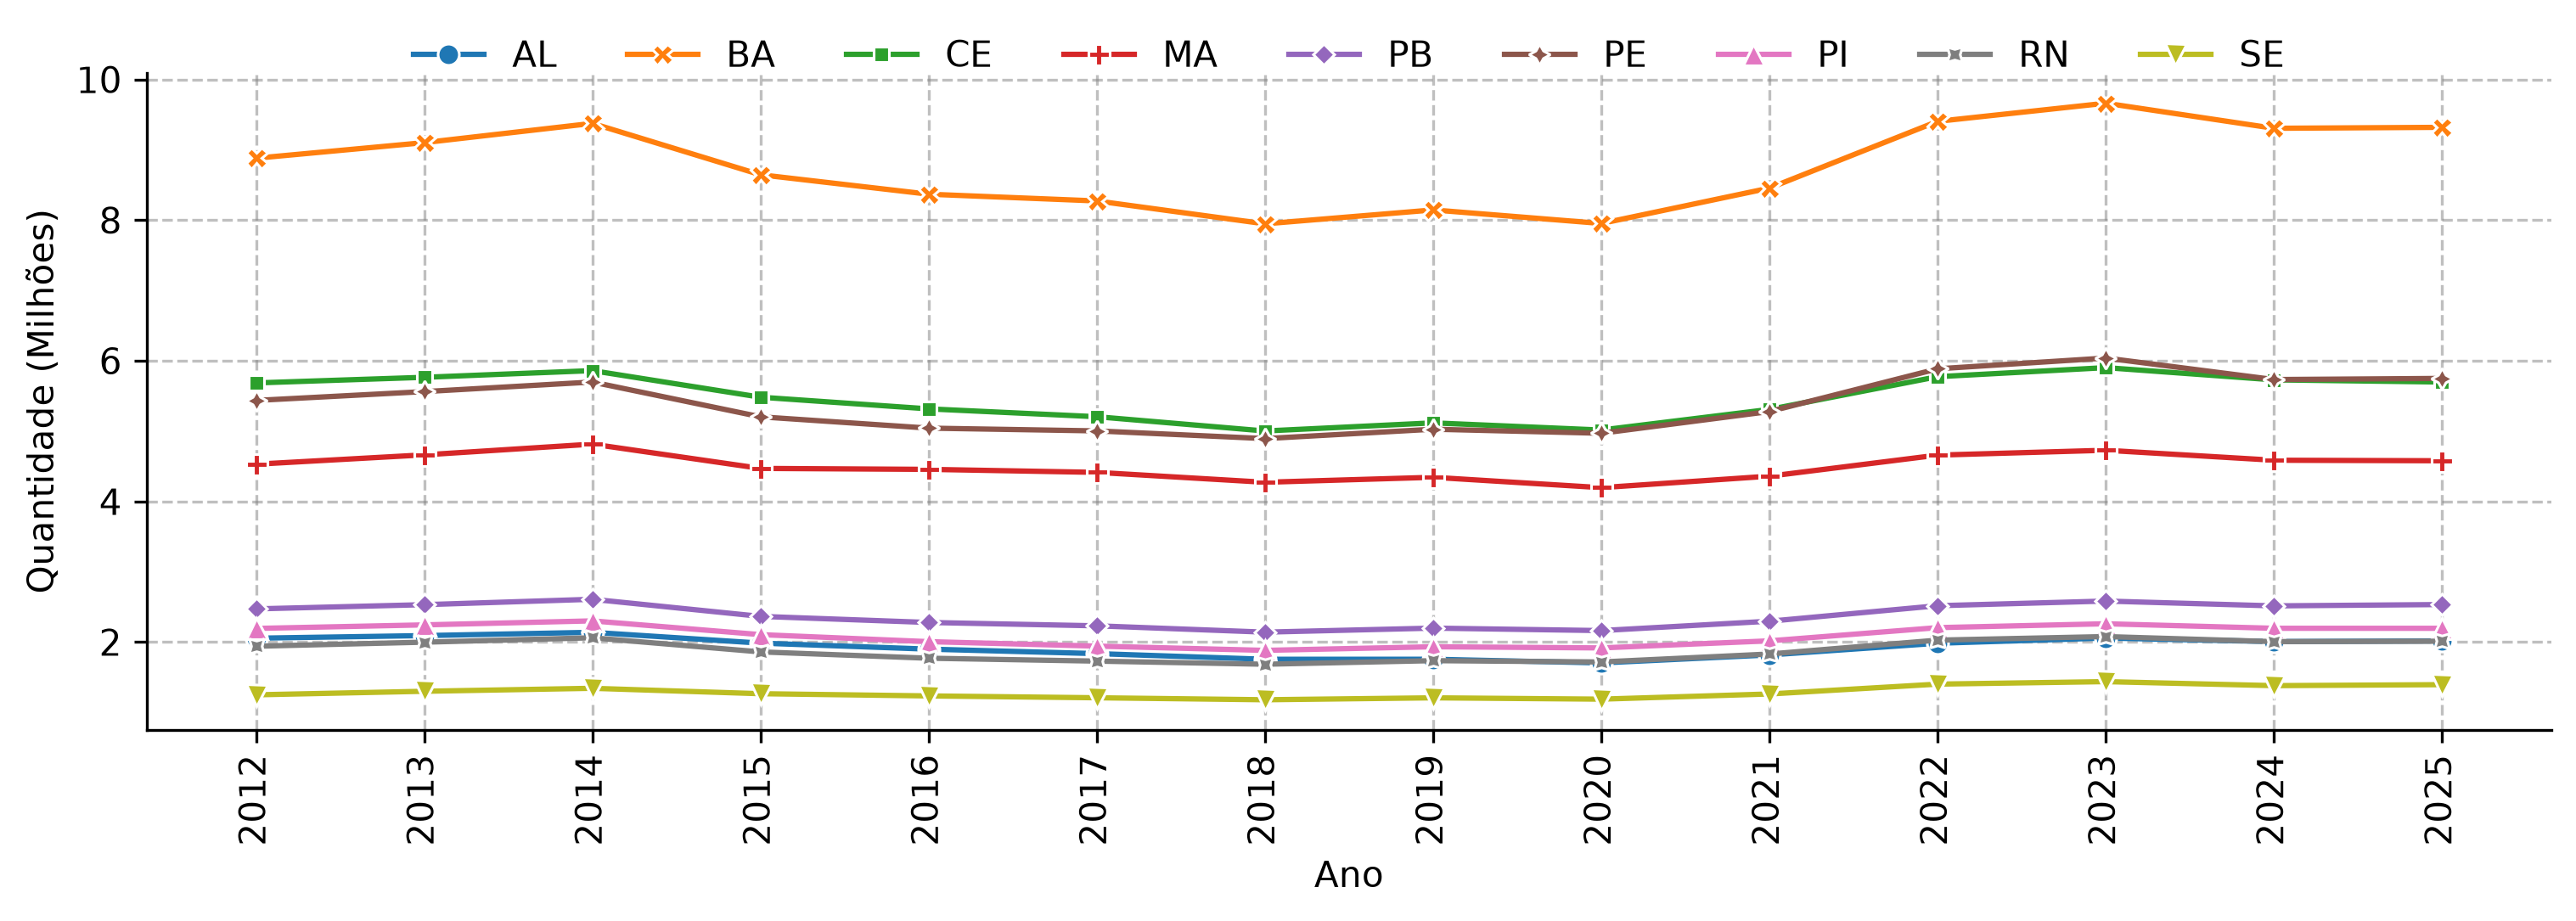

Norte


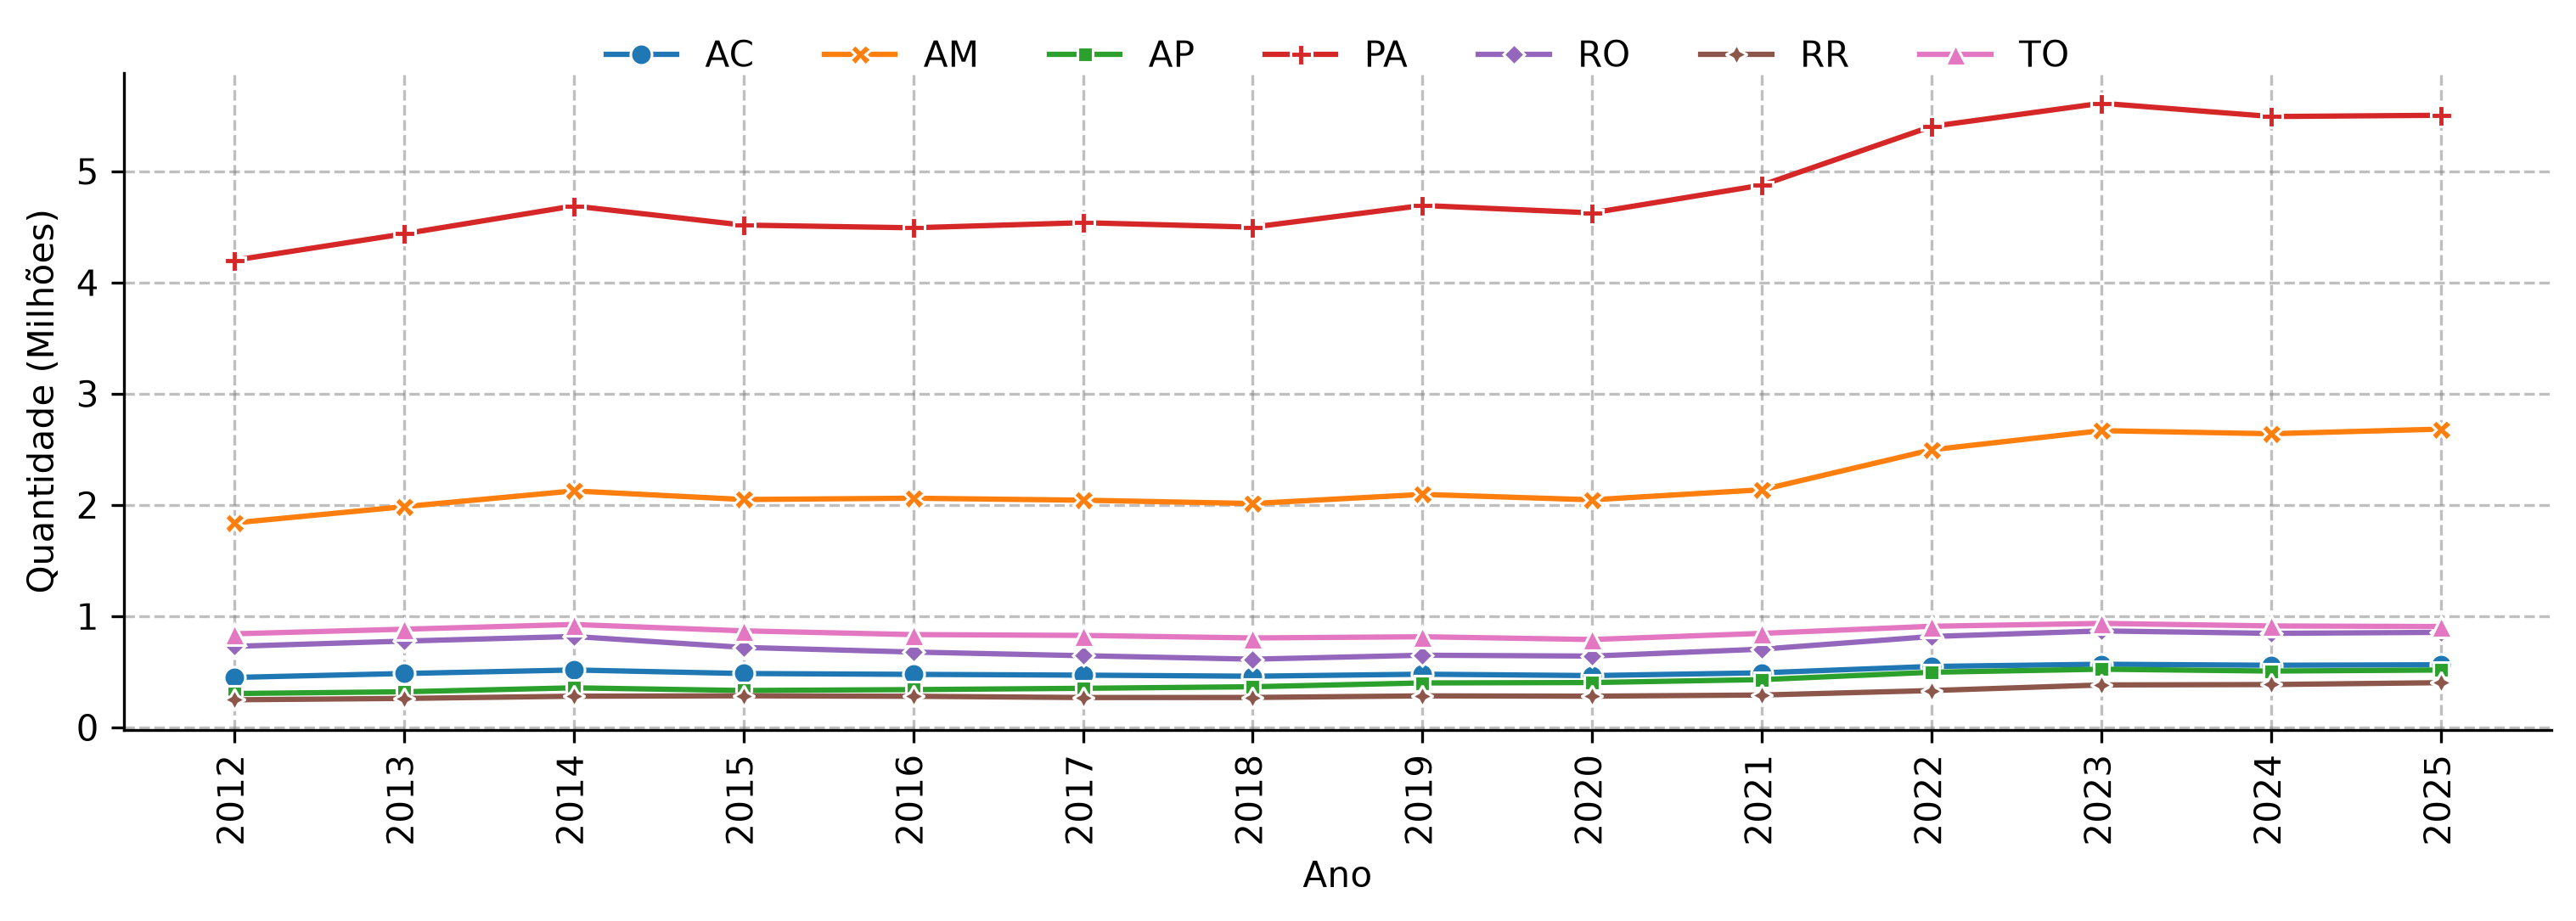

Sudeste


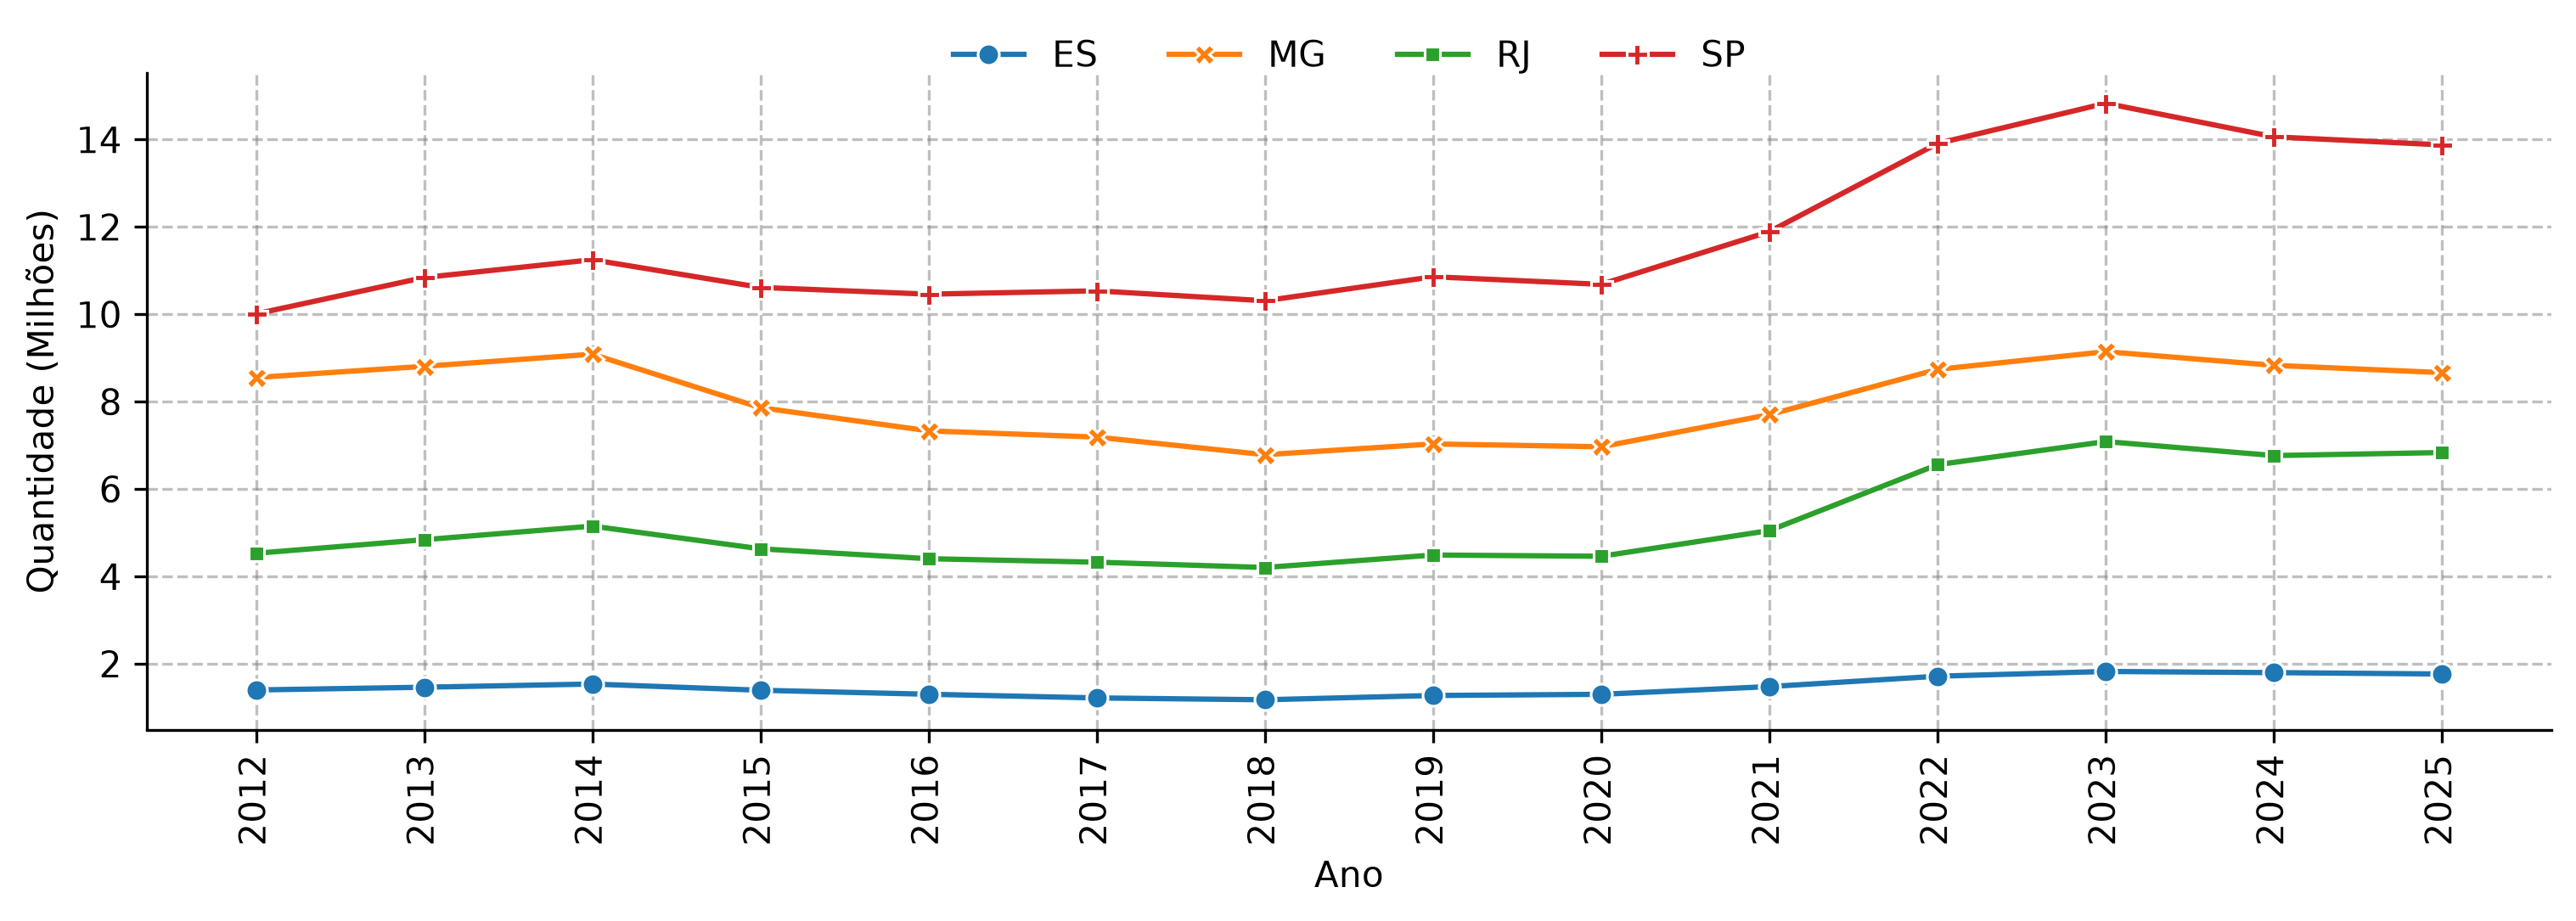

Sul


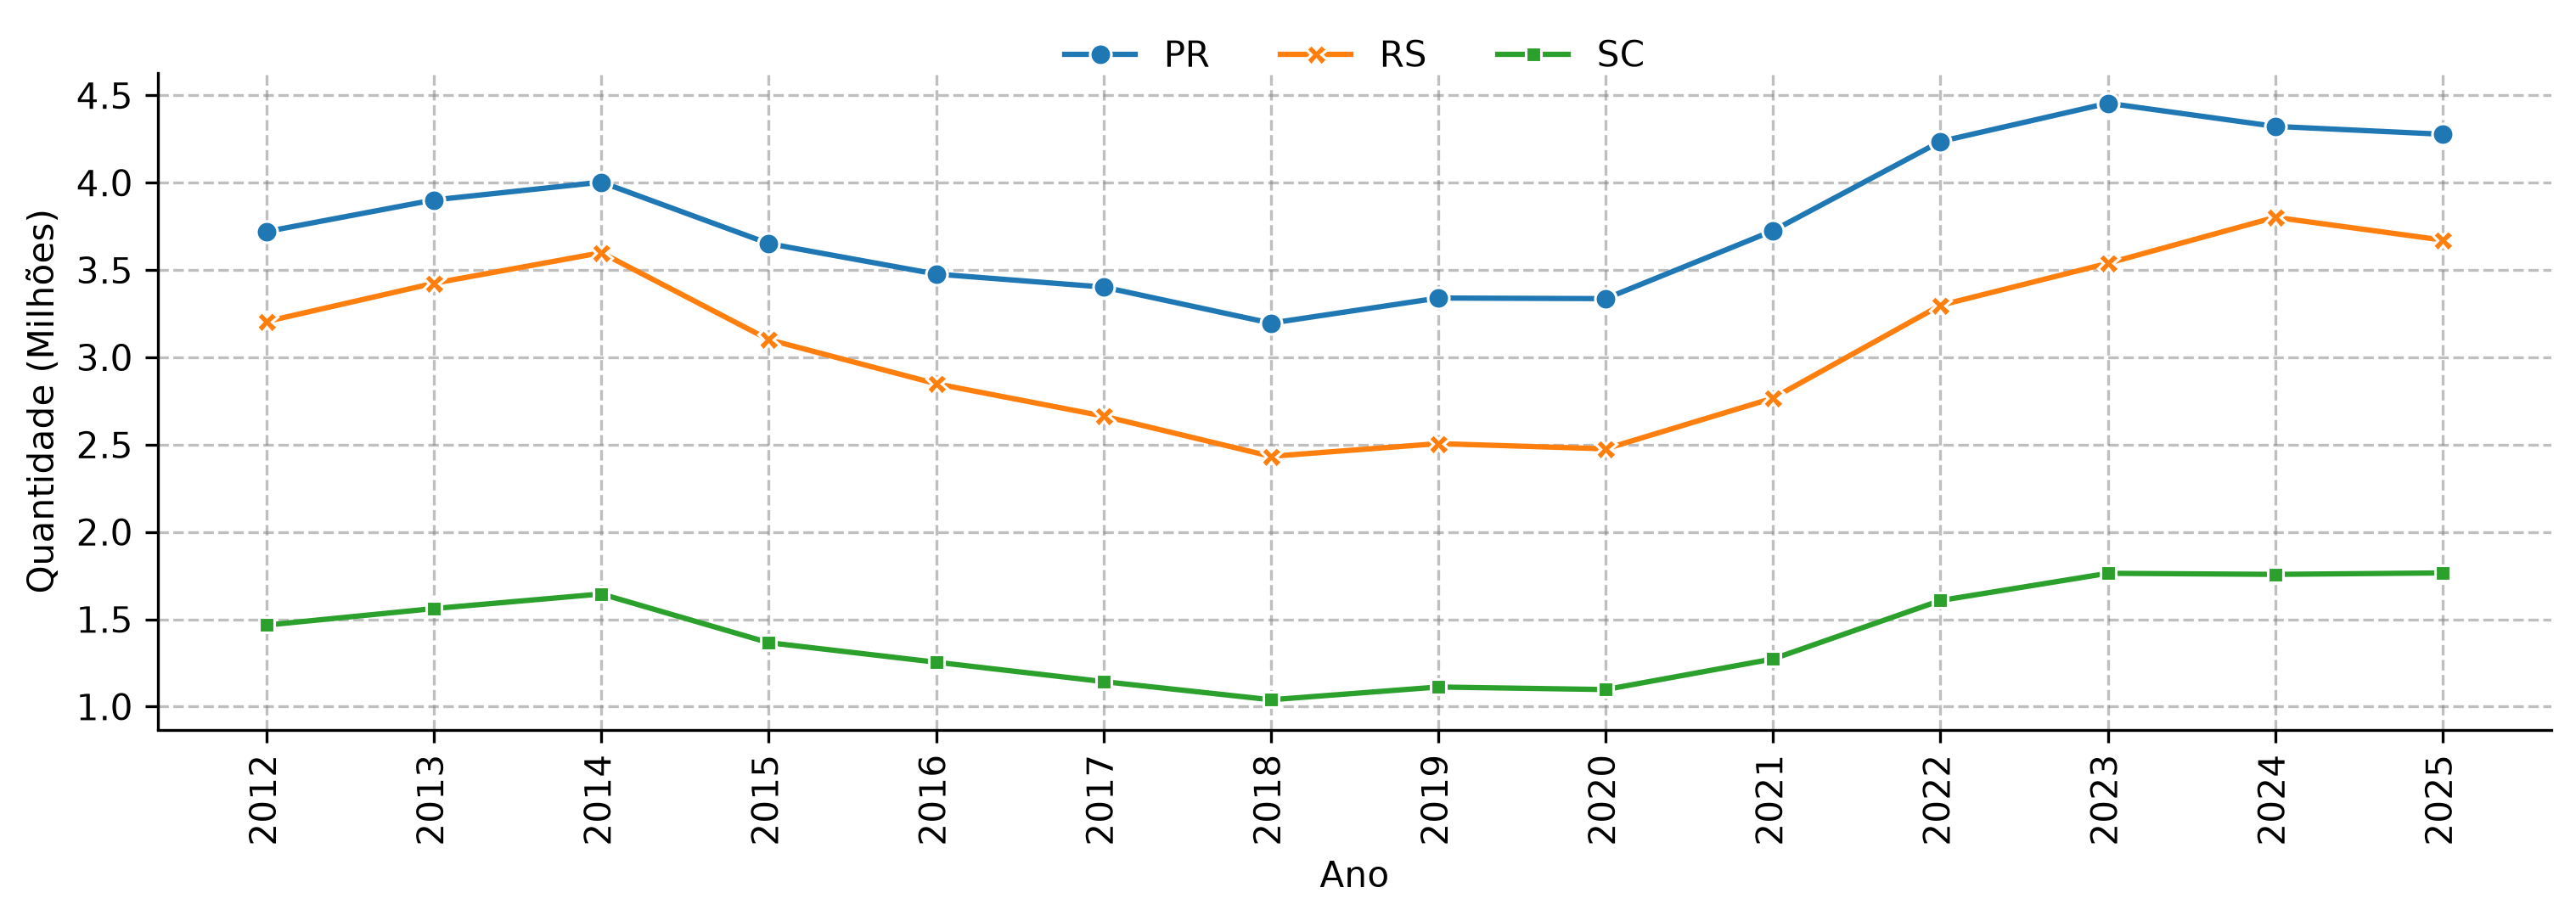

In [76]:
for (regiao, df_por_regiao) in df_qtde_por_ano_regiao_uf_grupo_pessoas.groupby('regiao'):
    print(regiao)

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='sigla_uf',
        style='sigla_uf',
        markers=True,
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=9, frameon=False)

    fig.savefig(f'pessoas_familias_cadunico_ufs_{regiao.lower()}_grupo_pessoas', dpi=300, bbox_inches='tight')
    plt.show()

In [77]:
df_qtde_por_ano_regiao_uf_grupo_familias = df_qtde_por_ano_regiao_uf.query('grupo == "Famílias"')

In [78]:
df_qtde_por_ano_regiao_uf_grupo_familias.head()

,ano,grupo,regiao,sigla_uf,qtde,qtde_1e6
27,2012,Famílias,Centro-oeste,DF,239813,0.239813
28,2012,Famílias,Centro-oeste,GO,740489,0.740489
29,2012,Famílias,Centro-oeste,MS,318332,0.318332
30,2012,Famílias,Centro-oeste,MT,394821,0.394821
31,2012,Famílias,Nordeste,AL,639697,0.639697


Centro-oeste


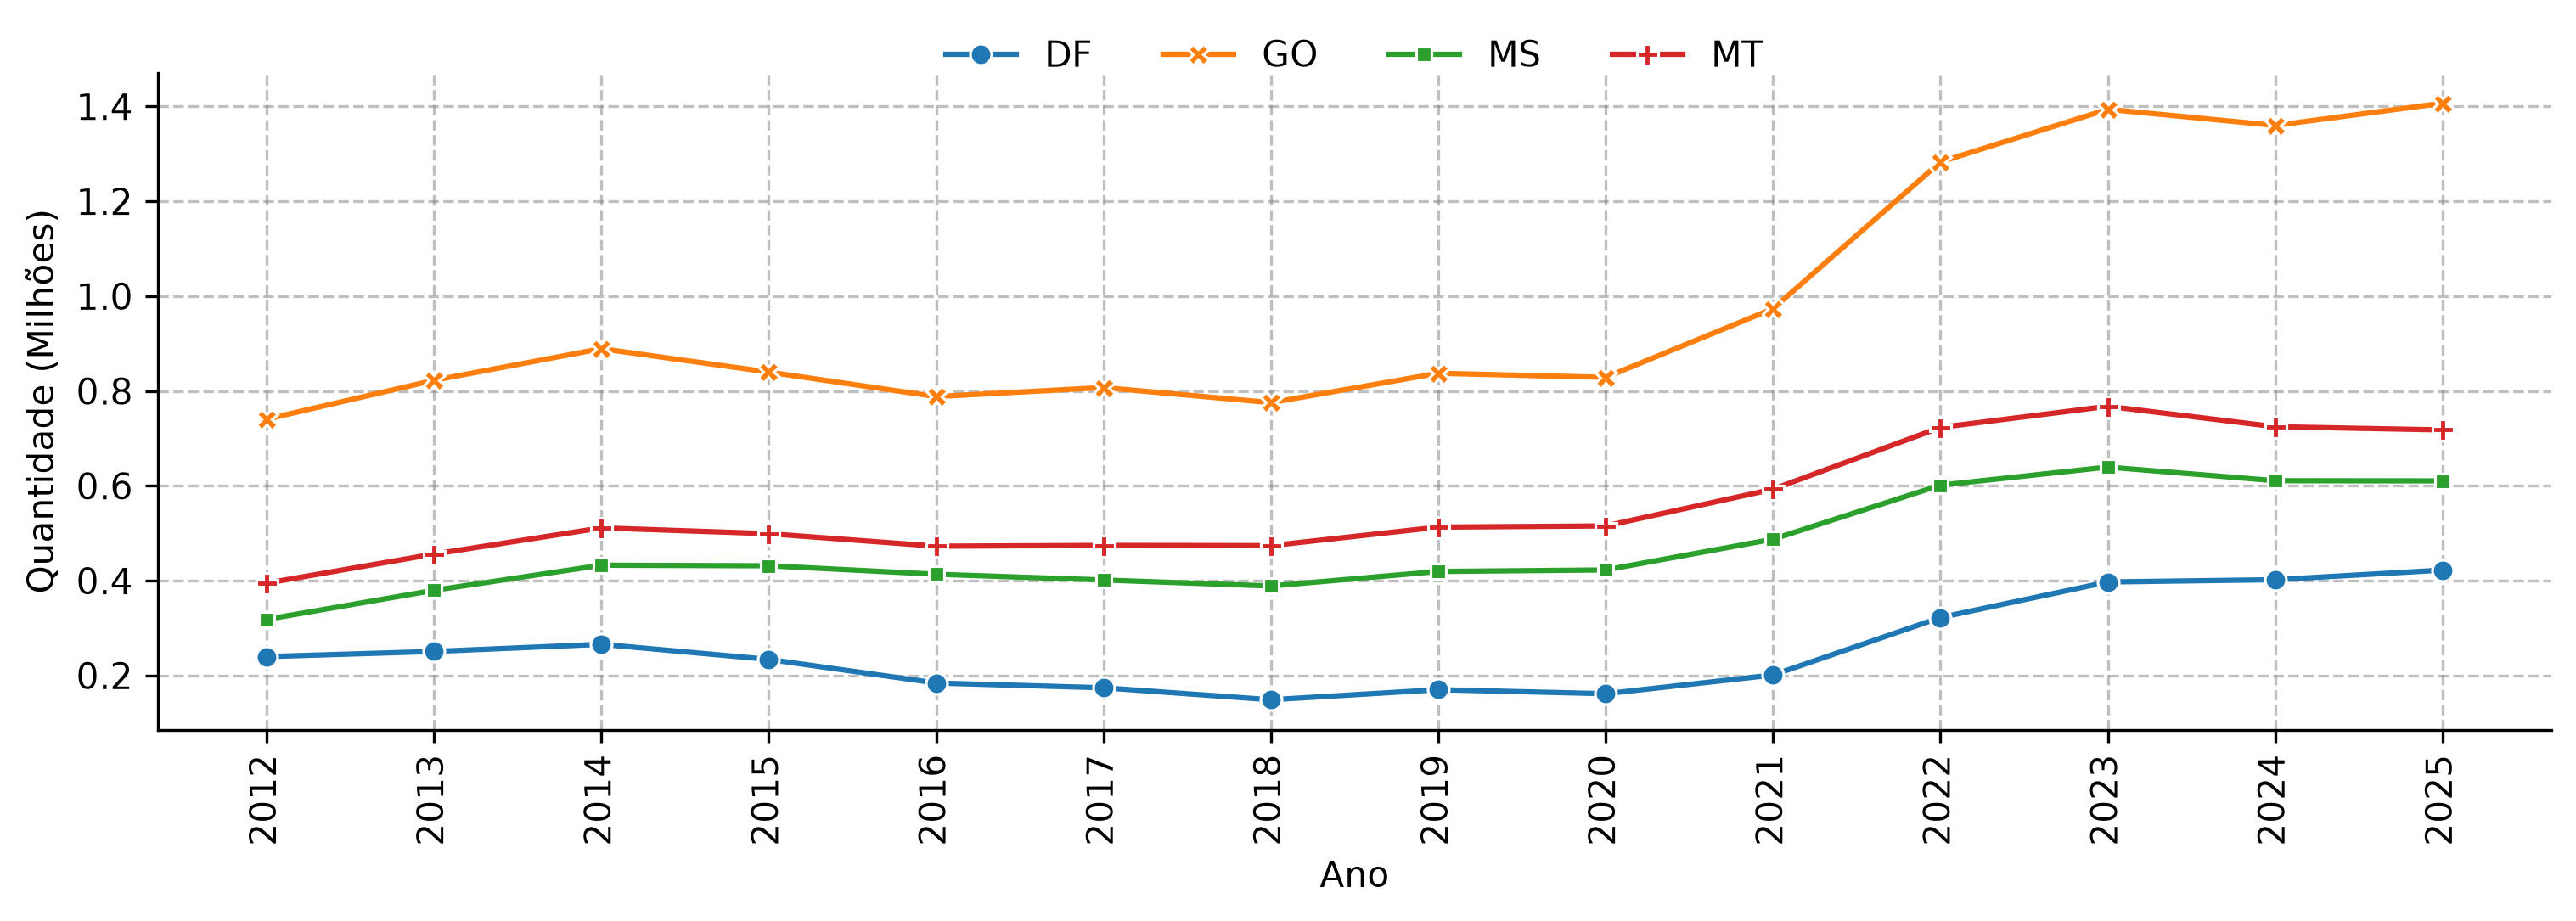

Nordeste


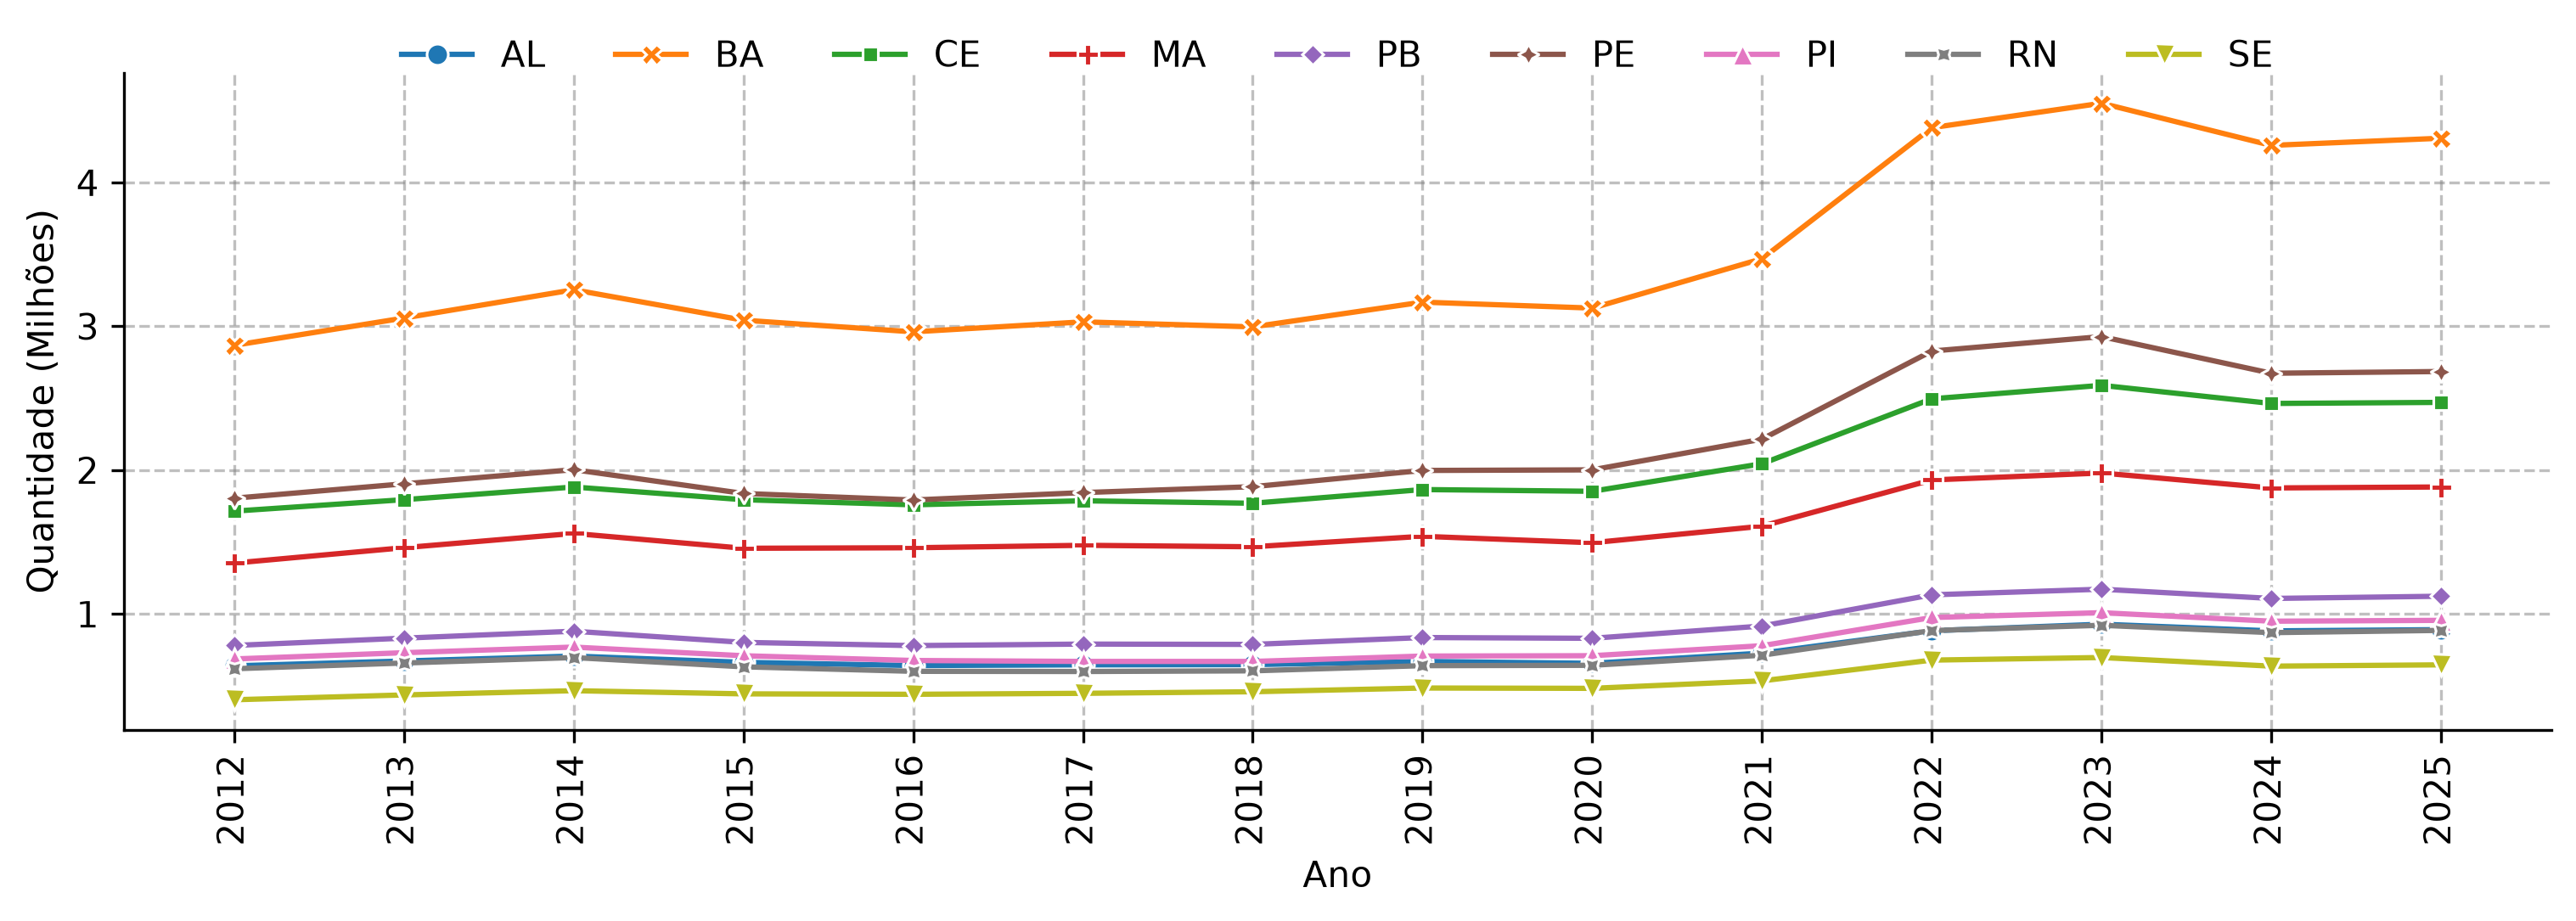

Norte


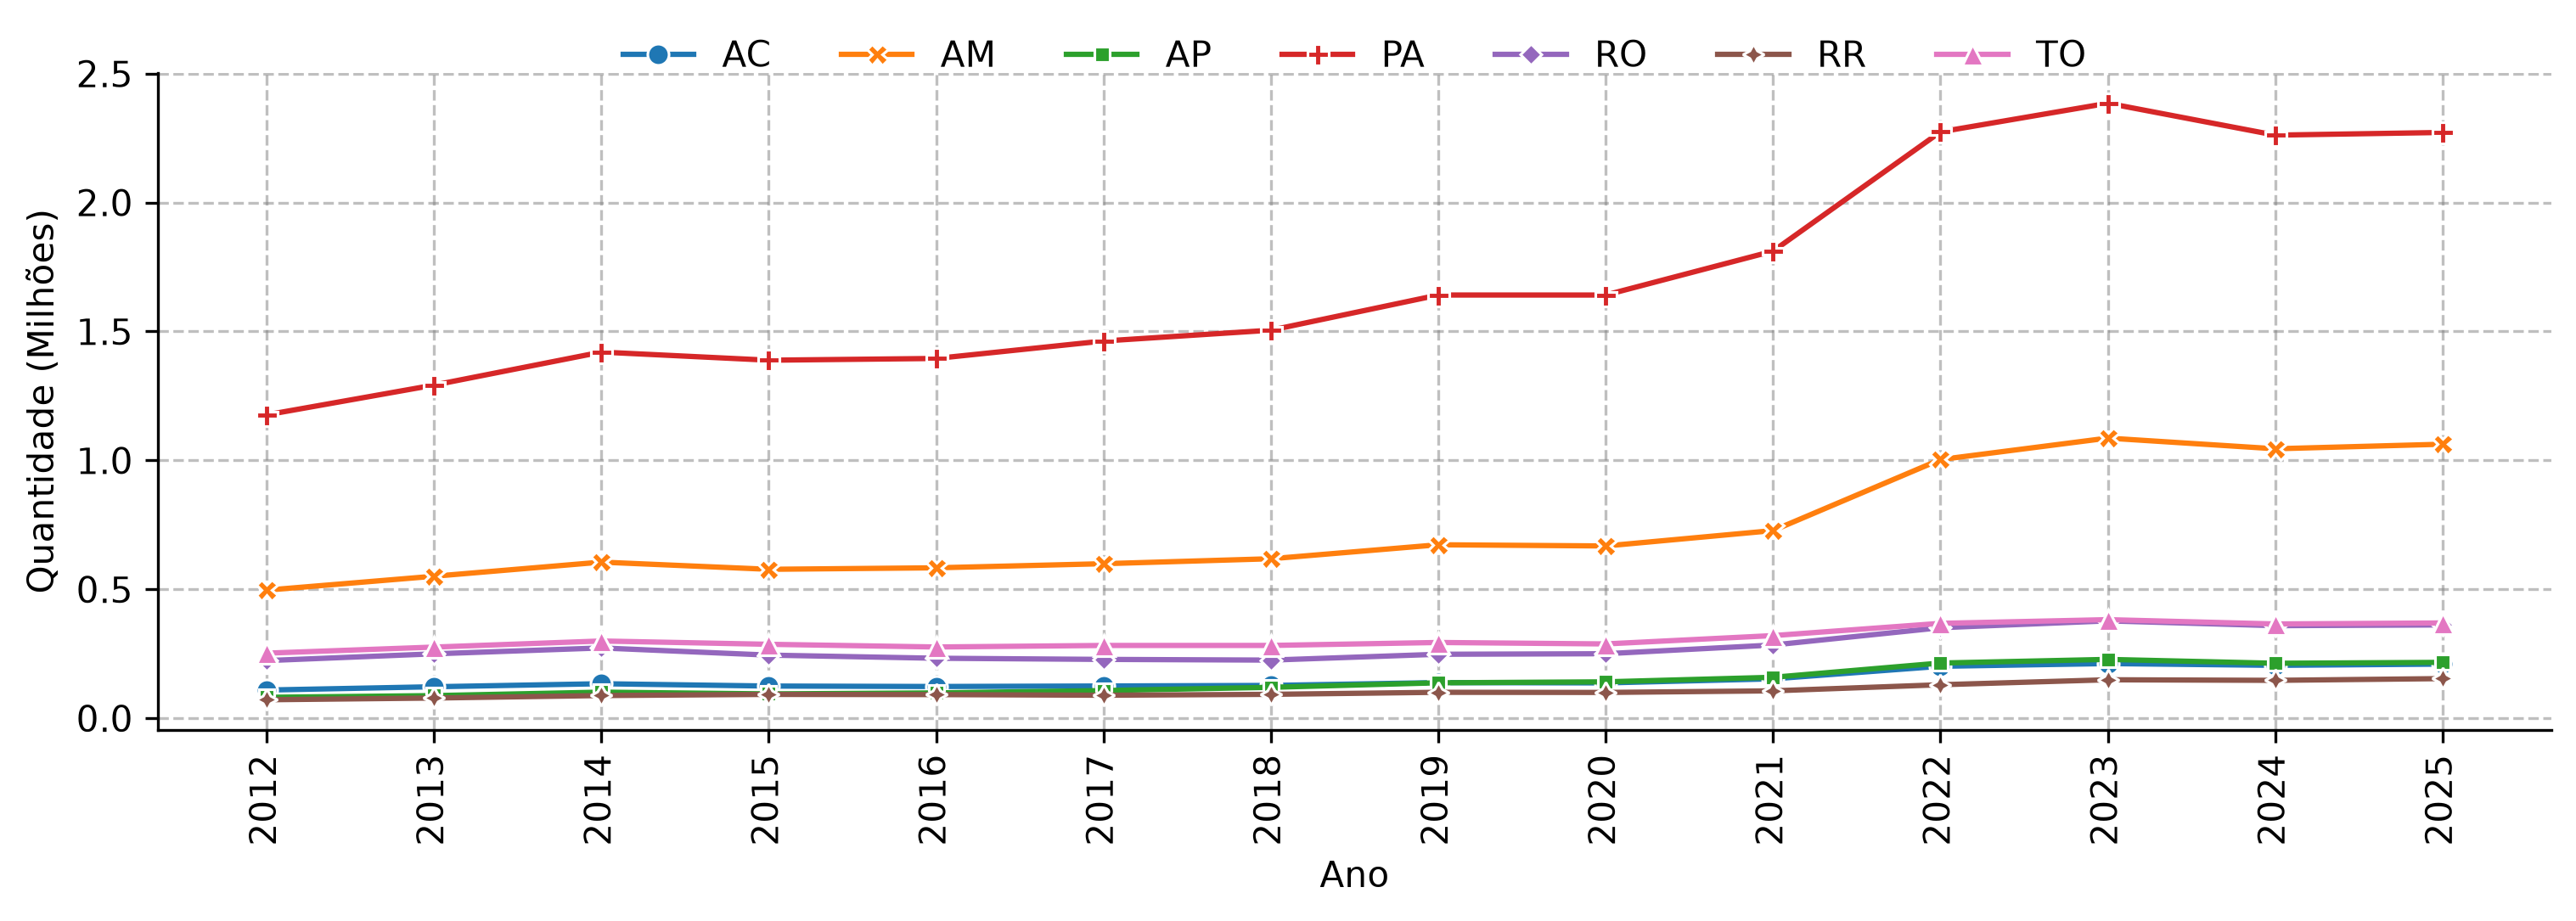

Sudeste


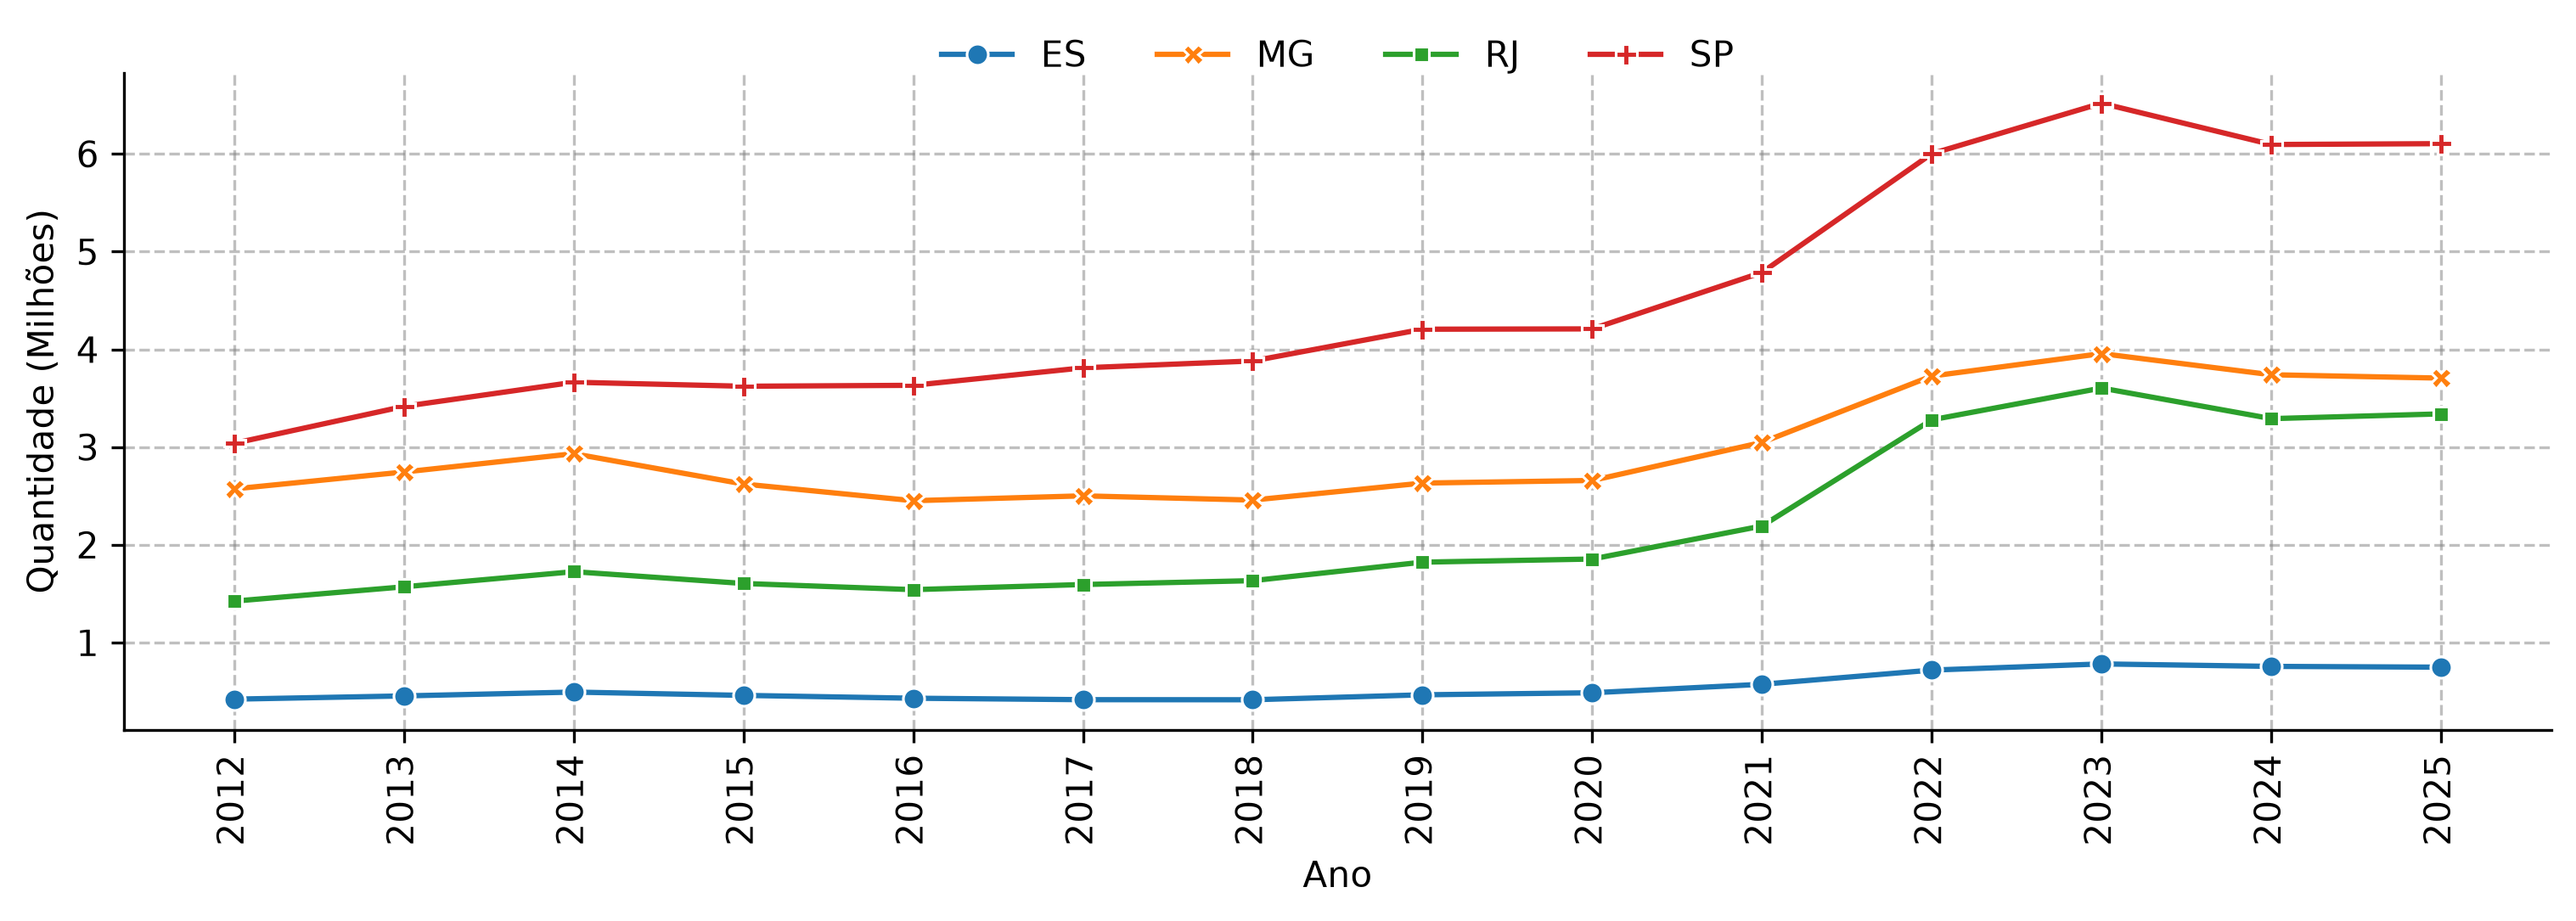

Sul


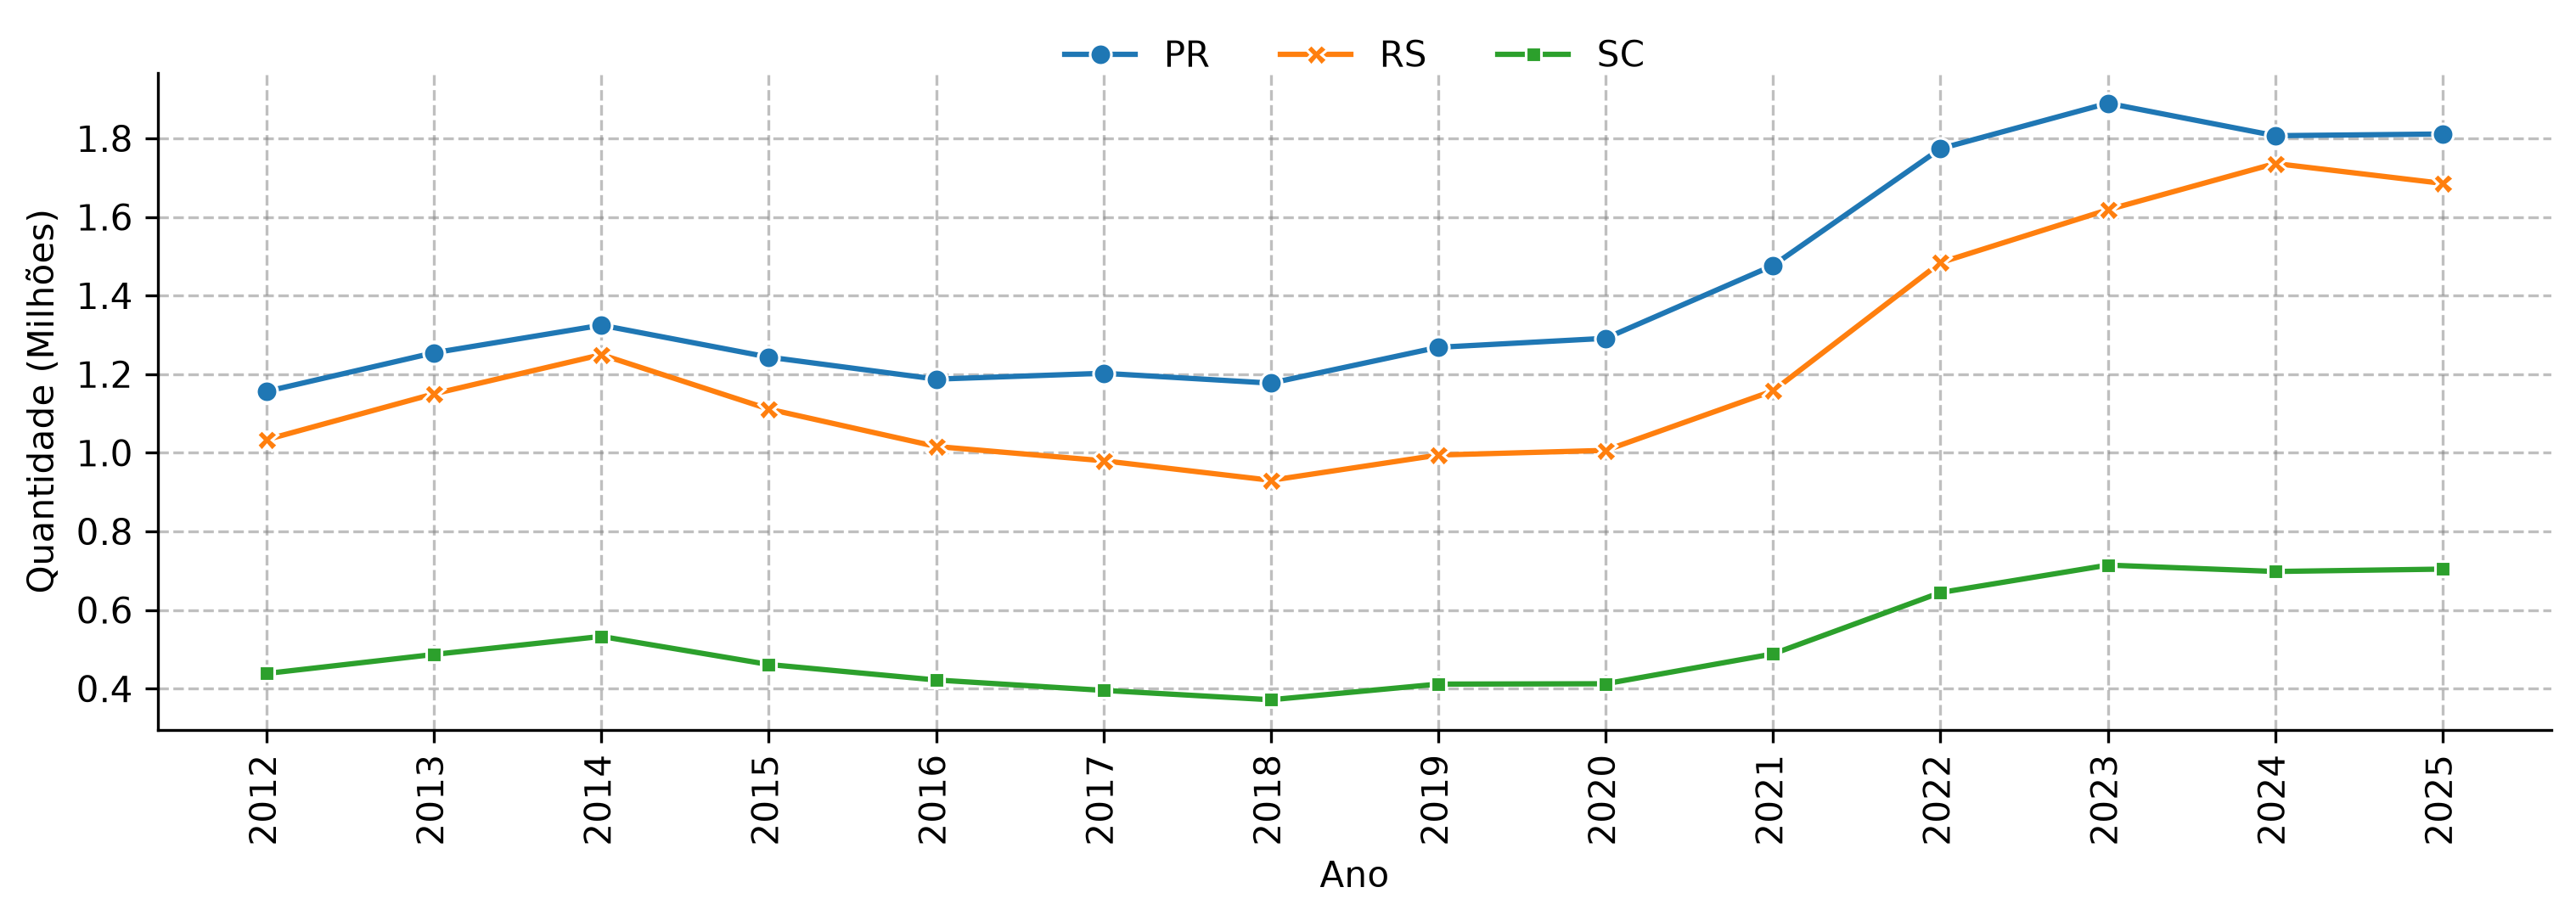

In [79]:
for (regiao, df_por_regiao) in df_qtde_por_ano_regiao_uf_grupo_familias.groupby('regiao'):
    print(regiao)

    fig, ax = plt.subplots(
        figsize=(10, 3.5),
        dpi=300,
        layout='constrained'
    )

    sns.lineplot(
        df_por_regiao,
        x='ano',
        y='qtde_1e6',
        hue='sigla_uf',
        style='sigla_uf',
        markers=True,
        errorbar=None,
        dashes=False,
        ax=ax
    )

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylabel('Quantidade (Milhões)')
    ax.set_xlabel('Ano')
    ax.set_xticks(anos, labels=anos, rotation=90)
    ax.grid(color='grey', linestyle='--', alpha=0.5)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncols=9, frameon=False)

    fig.savefig(f'pessoas_familias_cadunico_ufs_{regiao.lower()}_grupo_familias', dpi=300, bbox_inches='tight')
    plt.show()